In [1]:
from typing import TypedDict
import datetime as dt

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pyproj
import scipy
import etas.mc_b_est as mc_b_est
import etas.utility_functions as utility_functions
import etas.simulation as simulation
from etas.inversion import polygon_surface
from matplotlib import colors
from matplotlib.path import Path as MplPath
from scipy.optimize import root_scalar
from shapely.geometry import MultiPoint, MultiPolygon, Point, Polygon
from shapely.ops import transform, voronoi_diagram
from shapely.prepared import prep
from tqdm.auto import tqdm


2026-06-12 15:52:43.380296: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-12 15:52:43.415636: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-12 15:52:43.415673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-12 15:52:43.417181: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-12 15:52:43.423862: I tensorflow/core/platform/cpu_feature_guar

In [2]:
EARTH_RADIUS_KM = 6.3781e3


def _hav(theta):
    return np.square(np.sin(theta / 2))


def haversine_km(lat_rad_1, lat_rad_2, lon_rad_1, lon_rad_2, earth_radius=EARTH_RADIUS_KM):
    return (
        2
        * earth_radius
        * np.arcsin(
            np.sqrt(
                _hav(lat_rad_1 - lat_rad_2)
                + np.cos(lat_rad_1) * np.cos(lat_rad_2) * _hav(lon_rad_1 - lon_rad_2)
            )
        )
    )


def km_per_degree_at_latitude(lat_deg, earth_radius=EARTH_RADIUS_KM):
    lat_rad = np.radians(np.asarray(lat_deg, dtype=float))
    km_per_lat = haversine_km(
        lat_rad - np.radians(0.5), lat_rad + np.radians(0.5), 0.0, 0.0, earth_radius
    )
    km_per_lon = haversine_km(lat_rad, lat_rad, 0.0, np.radians(1.0), earth_radius)
    if np.ndim(km_per_lat) == 0:
        return float(km_per_lat), float(km_per_lon)
    return km_per_lat, km_per_lon


def latlon_rectangular_grid_in_polygon(
    polygon,
    grid_point_density_km2,
    *,
    earth_radius=EARTH_RADIUS_KM,
    rtol=0.05,
    max_iterations=40,
):
    if grid_point_density_km2 <= 0:
        raise ValueError("grid_point_density_km2 must be positive")
    area_km2 = float(polygon_surface(polygon))
    target_n = max(1, int(round(area_km2 * grid_point_density_km2)))
    min_lat, min_lon, max_lat, max_lon = polygon.bounds
    lat_c = 0.5 * (min_lat + max_lat)
    km_per_lat, km_per_lon = km_per_degree_at_latitude(lat_c, earth_radius)
    prep_poly = prep(polygon)
    spacing_km = float(np.sqrt(area_km2 / target_n))
    lat_flat = lon_flat = np.empty(0)
    n_lat = n_lon = 0
    for _ in range(max_iterations):
        spacing_lat = spacing_km / km_per_lat
        spacing_lon = spacing_km / km_per_lon
        n_lat = max(2, int(np.ceil((max_lat - min_lat) / spacing_lat)) + 1)
        n_lon = max(2, int(np.ceil((max_lon - min_lon) / spacing_lon)) + 1)
        lats = np.linspace(min_lat, max_lat, n_lat)
        lons = np.linspace(min_lon, max_lon, n_lon)
        lat_mesh, lon_mesh = np.meshgrid(lats, lons)
        lat_cand = lat_mesh.ravel()
        lon_cand = lon_mesh.ravel()
        inside = np.fromiter(
            (prep_poly.contains(Point(lat, lon)) for lat, lon in zip(lat_cand, lon_cand)),
            dtype=bool,
            count=lat_cand.size,
        )
        n_inside = int(inside.sum())
        if n_inside == 0:
            spacing_km *= 0.5
            continue
        lat_flat = lat_cand[inside]
        lon_flat = lon_cand[inside]
        if abs(n_inside - target_n) / target_n <= rtol:
            break
        spacing_km *= np.sqrt(n_inside / target_n)
    if lat_flat.size == 0:
        raise RuntimeError("Could not place any grid nodes inside the polygon")
    info = {
        "area_km2": area_km2,
        "target_n": target_n,
        "n_points": int(lat_flat.size),
        "spacing_km": spacing_km,
        "grid_n_xy": (n_lat, n_lon),
        "grid_point_density_km2": float(grid_point_density_km2),
    }
    return lat_flat, lon_flat, info


def _swap_xy(x, y):
    return y, x


def get_ordered_voronoi_cells(polygon_latlon, lat_flat, lon_flat):
    # Swap bounding polygon to standard (lon, lat)
    polygon_lonlat = transform(_swap_xy, polygon_latlon)

    # Create ordered points
    points = [Point(lon, lat) for lon, lat in zip(lon_flat, lat_flat)]

    # Generate raw Voronoi diagram
    vd = voronoi_diagram(MultiPoint(points), envelope=polygon_lonlat)
    raw_cells = list(vd.geoms)

    # Use spatial join to map the unordered cells back to the exact order of input points
    points_gdf = gpd.GeoDataFrame(geometry=points)
    cells_gdf = gpd.GeoDataFrame(geometry=raw_cells)
    matched = points_gdf.sjoin(cells_gdf, how="left", predicate="intersects")
    matched = matched[~matched.index.duplicated(keep="first")]

    ordered_clipped_cells = []
    for idx in matched["index_right"].values:
        if np.isnan(idx):
            # Point is completely orphaned/outside
            ordered_clipped_cells.append(Polygon())
        else:
            # Extract matched cell and clip it to the overarching polygon boundary
            cell = raw_cells[int(idx)]
            clipped_cell = cell.intersection(polygon_lonlat)
            ordered_clipped_cells.append(clipped_cell)

    return ordered_clipped_cells


In [3]:
# Grid points per side for A_h spatial quadrature (log_rhs, inverse transform, saved CSV tag).
A_H_RESOLUTION = 40

class History(TypedDict):
    m: float
    x: float
    y: float
    t: float

class EtasParams(TypedDict):
    mu: float
    k0: float
    a: float
    m_c: float
    d: float
    gamma: float
    rho: float
    c: float
    tau: float
    omega: float

def a_h(
    x: float,
    y: float,
    H: History,
    params: EtasParams,
):
    """Spatial triggering kernel at (x, y) = (lon, lat) from history event H."""
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        y, x, H["y"], H["x"]
    )
    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    return K / (dist_sq_km2 + C) ** (1 + params["rho"])


def A_h(poly: Polygon, H: History, params: EtasParams, resolution: int = 50) -> float:
    """Integrate a_h over poly; poly vertices are (lon, lat)."""
    minx, miny, maxx, maxy = poly.bounds
    if minx == maxx or miny == maxy:
        return 0.0

    x_grid = np.linspace(minx, maxx, resolution)
    y_grid = np.linspace(miny, maxy, resolution)
    X, Y = np.meshgrid(x_grid, y_grid)

    points = np.column_stack((X.ravel(), Y.ravel()))
    path = MplPath(poly.exterior.coords)
    mask = path.contains_points(points).reshape(resolution, resolution)

    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    rho1 = 1 + params["rho"]

    X_masked = X[mask]
    Y_masked = Y[mask]
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        Y_masked, X_masked, H["y"], H["x"]
    )
    kernel = K / (dist_sq_km2 + C) ** rho1

    dlon_deg = (maxx - minx) / (resolution - 1)
    dlat_deg = (maxy - miny) / (resolution - 1)
    km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(Y_masked)
    dA_km2 = (dlon_deg * km_per_lon) * (dlat_deg * km_per_lat)

    return float(np.sum(kernel * dA_km2))

def polygon_area(polygon: Polygon) -> float:
    geod = pyproj.Geod(ellps="WGS84")
    area_m2, _ = geod.geometry_area_perimeter(polygon)
    return abs(area_m2) / 1e6

def g(
    t: float,
    H : History,
    params: EtasParams,
    ):
    return np.exp(-(t - H['t']) / params['tau']) / (t - H['t'] + params['c'])**(1+params['omega'])

def etas_rate_at_xy(
    x: float,
    y: float,
    t: float,
    H : History,
    params: EtasParams,
    ):
    return params['mu']  + a_h(x, y, H, params) * g(t, H, params)

def unreg_gamma(a, x):
    return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)


In [4]:
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
    "m_c": 3.5,
}

for key in list(THETA_0.keys()):
    if key.startswith('log10_'):
        xx = key.replace('log10_', '')
        if xx not in THETA_0:
            THETA_0[xx] = 10 ** THETA_0[key]


THETA_0


{'log10_mu': -5.8,
 'log10_k0': -2.6,
 'a': 1.8,
 'log10_c': -2.5,
 'omega': -0.02,
 'log10_tau': 3.5,
 'log10_d': -0.85,
 'gamma': 1.3,
 'rho': 0.66,
 'm_c': 3.5,
 'mu': 1.584893192461114e-06,
 'k0': 0.0025118864315095794,
 'c': 0.0031622776601683794,
 'tau': 3162.2776601683795,
 'd': 0.14125375446227545}

In [5]:
history_event_time = "2006-12-29 00:00:00"
history_event_magnitude = 6.5
history_event_x = -116.4
history_event_y = 33.6

history_dict = {
    "m": history_event_magnitude,
    "x": history_event_x,
    "y": history_event_y,
    "t": (pd.to_datetime(history_event_time) - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"),
}


In [6]:
# Hardcoded study-region outline (same vertices as input_data/california_shape.npy)
# Each row is [latitude, longitude].
SHAPE_COORDS = [[43.5, -125.7], [43.5, -118.5], [39.7, -118.5], [36.1, -113.6], [34.6, -112.6], [34.3, -112.6], [32.7, -113.1], [31.8, -113.2], [31.2, -114.5], [31.0, -117.1], [31.1, -117.4], [31.5, -118.3], [32.4, -118.8], [33.3, -121.3], [34.0, -122.0], [37.5, -124.3], [40.0, -125.9], [40.5, -125.9], [43.0, -125.7], [43.5, -125.7]]

GRID_POINT_DENSITY_KM2 = 5e-4  # same as grid_recreations_point_process.ipynb


In [7]:
polygon = Polygon(SHAPE_COORDS)

lat_flat, lon_flat, grid_info = latlon_rectangular_grid_in_polygon(
    polygon, GRID_POINT_DENSITY_KM2
)
ordered_cells = get_ordered_voronoi_cells(polygon, lat_flat, lon_flat)

print(
    f"grid from density {GRID_POINT_DENSITY_KM2:.4g} pts/km²: "
    f"{grid_info['n_points']} nodes (target {grid_info['target_n']}, "
    f"spacing {grid_info['spacing_km']:.3f} km, rectangle {grid_info['grid_n_xy']})"
)
print(f"polygon area: {grid_info['area_km2']:.4g} km²")
print(f"Voronoi cells: {len(ordered_cells)}")

history_point = Point(history_event_x, history_event_y)
for j, cell in enumerate(ordered_cells):
    if cell.contains(history_point):
        print(
            f"history point ({history_event_x}, {history_event_y}) -> cell {j}, "
            f"node ({lon_flat[j]:.6f}, {lat_flat[j]:.6f})"
        )
        break


grid from density 0.0005 pts/km²: 494 nodes (target 480, spacing 44.717 km, rectangle (33, 28))
polygon area: 9.598e+05 km²
Voronoi cells: 494
history point (-116.4, 33.6) -> cell 390, node (-116.540741, 33.734375)


2026-06-12 15:52:45,775 - DEBUG - Loaded backend inline version unknown.
2026-06-12 15:52:45,780 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-12 15:52:45,780 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-12 15:52:45,781 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-12 15:52:45,781 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-pa

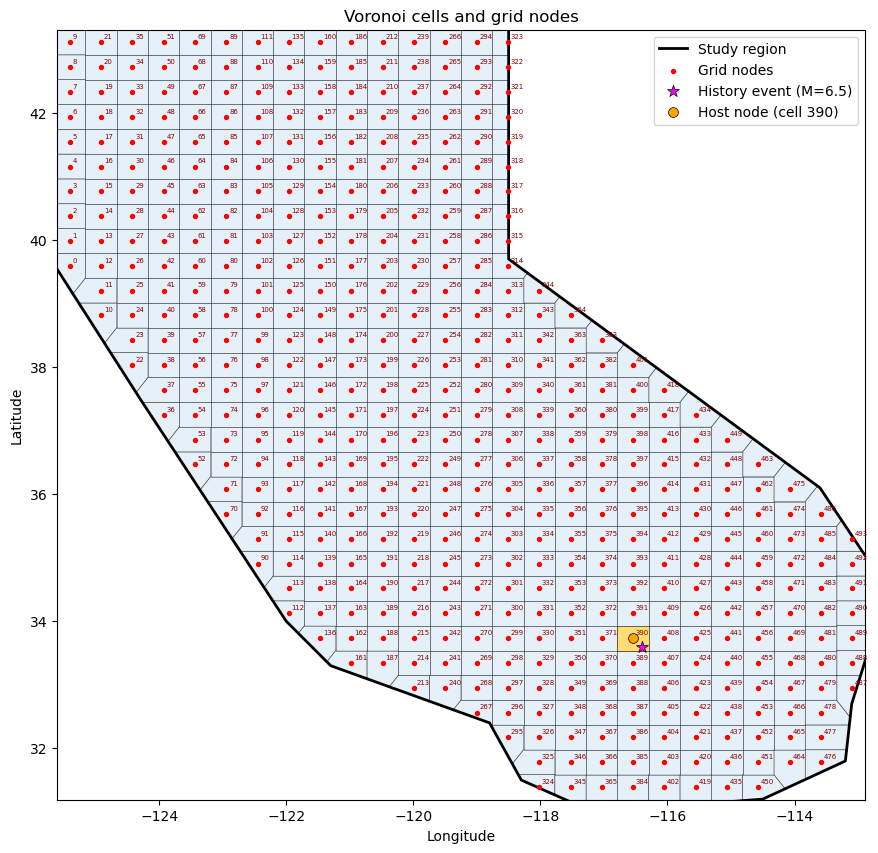

In [8]:
%matplotlib inline



def _polygon_parts(geom):
    if geom.is_empty:
        return
    if geom.geom_type == "Polygon":
        yield geom
    elif geom.geom_type == "MultiPolygon":
        yield from geom.geoms
    elif geom.geom_type == "GeometryCollection":
        for g in geom.geoms:
            yield from _polygon_parts(g)


history_cell_idx = None
for j, cell in enumerate(ordered_cells):
    if cell.contains(history_point):
        history_cell_idx = j
        break

fig_grid, ax = plt.subplots(figsize=(12, 10))

for j, cell in enumerate(ordered_cells):
    facecolor = "#ffd966" if j == history_cell_idx else "#d9e8f7"
    alpha = 0.9 if j == history_cell_idx else 0.65
    for part in _polygon_parts(cell):
        xy = np.asarray(part.exterior.coords)  # x=lon, y=lat
        ax.add_patch(
            mpatches.Polygon(
                xy,
                closed=True,
                facecolor=facecolor,
                edgecolor="k",
                alpha=alpha,
                linewidth=0.4,
            )
        )

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")

ax.scatter(lon_flat, lat_flat, s=8, c="red", zorder=5, label="Grid nodes")
for j in range(len(lon_flat)):
    ax.annotate(
        str(j),
        (lon_flat[j], lat_flat[j]),
        textcoords="offset points",
        xytext=(2, 2),
        fontsize=5,
        color="darkred",
        ha="left",
        va="bottom",
        zorder=7,
    )
ax.scatter(
    [history_event_x],
    [history_event_y],
    s=80,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

if history_cell_idx is not None:
    ax.scatter(
        [lon_flat[history_cell_idx]],
        [lat_flat[history_cell_idx]],
        s=50,
        c="orange",
        edgecolors="black",
        linewidths=0.5,
        zorder=6,
        label=f"Host node (cell {history_cell_idx})",
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Voronoi cells and grid nodes")
ax.set_aspect("equal")
ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


2026-06-12 15:52:47,580 - DEBUG - locator: <matplotlib.ticker.LogLocator object at 0x7661e1eee190>
2026-06-12 15:52:47,879 - DEBUG - vmin 1.5915767684475103e-06 vmax 0.007265277536024621
2026-06-12 15:52:47,880 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01])
2026-06-12 15:52:47,884 - DEBUG - vmin 1.5915767684475103e-06 vmax 0.007265277536024621
2026-06-12 15:52:47,884 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01])
2026-06-12 15:52:47,885 - DEBUG - vmin 1.5915767684475103e-06 vmax 0.00726527

2026-06-12 15:52:50,636 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/tlwg/Umpush-Light.ttf', name='Umpush', style='normal', variant='normal', weight=300, stretch='normal', size='scalable')) = 10.145
2026-06-12 15:52:50,636 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/lato/Lato-ThinItalic.ttf', name='Lato', style='italic', variant='normal', weight=200, stretch='normal', size='scalable')) = 11.24
2026-06-12 15:52:50,636 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/noto/NotoSansSinhala-Regular.ttf', name='Noto Sans Sinhala', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-12 15:52:50,636 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/magnet_env/fonts/SourceCodePro-SemiboldIt.ttf', name='Source Code Pro', style='italic', variant='normal', weight=600, stretch='normal', size='scalable')) = 11.24
2026-06-12 15:52:50,637 - 

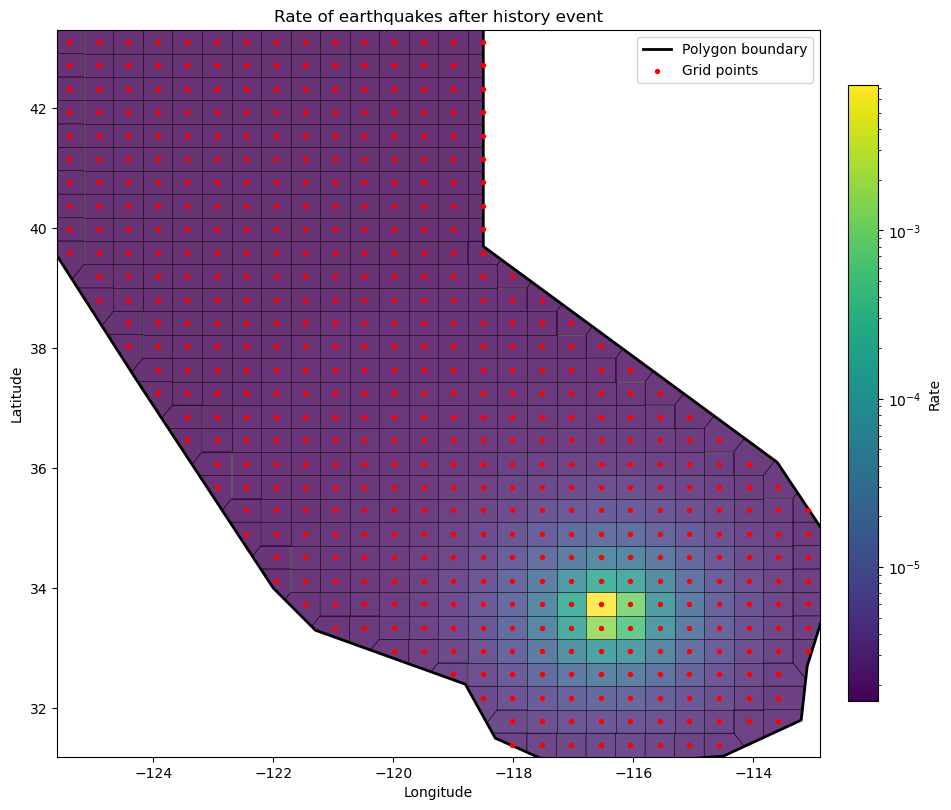

In [9]:
# calculate rate for each grid point after history event
epsilon = 1e-4
rates = etas_rate_at_xy(lon_flat, lat_flat, history_dict["t"] + epsilon, history_dict, THETA_0)



def _polygon_parts(geom):
    if geom.is_empty:
        return
    if geom.geom_type == "Polygon":
        yield geom
    elif geom.geom_type == "MultiPolygon":
        yield from geom.geoms
    elif geom.geom_type == "GeometryCollection":
        for g in geom.geoms:
            yield from _polygon_parts(g)


# Same clipped Voronoi cells as grid_recreations_point_process.ipynb (fig_rate cell).
fig, ax = plt.subplots(figsize=(12, 10))
norm = colors.LogNorm(vmin=np.min(rates), vmax=np.max(rates))
cmap = plt.cm.viridis

for j, cell in enumerate(ordered_cells):
    color = cmap(norm(rates[j]))
    for part in _polygon_parts(cell):
        xy = np.asarray(part.exterior.coords)  # x=lon, y=lat
        ax.add_patch(
            mpatches.Polygon(
                xy,
                closed=True,
                facecolor=color,
                edgecolor="k",
                alpha=0.8,
                linewidth=0.4,
            )
        )

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Polygon boundary")

ax.scatter(lon_flat, lat_flat, s=8, c="red", zorder=5, label="Grid points")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.03)
cbar.set_label("Rate")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Rate of earthquakes after history event")
ax.set_aspect("equal")
ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend()
plt.show()


### time to next event


In [10]:
t_prime_vec = np.linspace(0, 100, 300) + history_dict['t']

second_gamma = unreg_gamma(-THETA_0['omega'], THETA_0['c'] / THETA_0['tau'])

def log_rhs(t_prime: float, t: float, target_polygon: Polygon, H: History, params: EtasParams, resolution: int = 50):
    """
    Computes the log-space right-hand side for numerical stability.
    """
    t_h = H['t']
    
    # Linear background term
    term1 = -polygon_area(target_polygon) * params['mu'] * (t_prime - t)
    
    # Non-linear triggering term
    gamma_diff = (
        unreg_gamma(-params['omega'], (params['c'] + t_prime - t_h) / params['tau']) - 
        unreg_gamma(-params['omega'], (params['c'] + t - t_h) / params['tau'])
    )
    
    const_multiplier = np.exp(params['c'] / params['tau']) / (params['tau']**(-params['omega']))
    term2 = A_h(target_polygon, H, params, resolution) * const_multiplier * gamma_diff
    
    return term1 + term2

all_P_vecs = []
for cell in ordered_cells:
    rhs_vec = np.exp(log_rhs(t_prime_vec, history_dict['t'], cell, history_dict, THETA_0, A_H_RESOLUTION))
    all_P_vecs.append(rhs_vec)





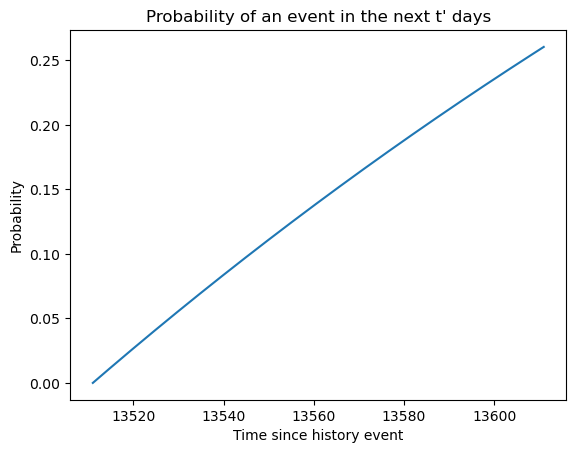

In [11]:
f, ax = plt.subplots()
ax.plot(t_prime_vec, 1 - all_P_vecs[250])
ax.set_xlabel("Time since history event")
ax.set_ylabel("Probability")
ax.set_title("Probability of an event in the next t' days")
plt.show()


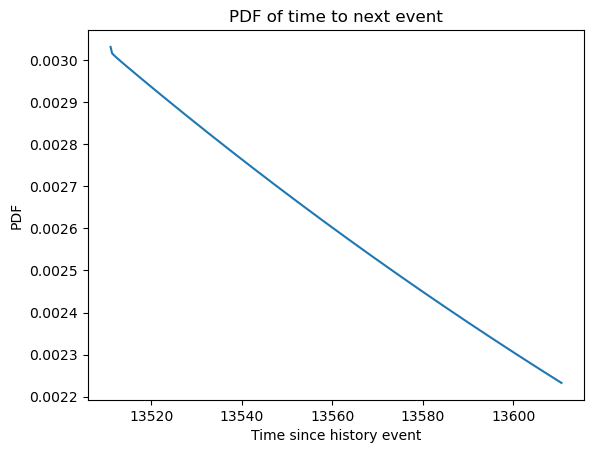

In [12]:
# pdf
pdf = np.diff(1 - all_P_vecs[250]) / np.diff(t_prime_vec)

f, ax = plt.subplots()
ax.plot(t_prime_vec[:-1], pdf)
ax.set_xlabel("Time since history event")
ax.set_ylabel("PDF")
ax.set_title("PDF of time to next event")
plt.show()


In [13]:
t_prime_vec = np.linspace(0, 100, 300) + history_dict['t']

second_gamma = unreg_gamma(-THETA_0['omega'], THETA_0['c'] / THETA_0['tau'])


# Raw SHAPE_COORDS polygon is (lat, lon); swap to (lon, lat) for A_h / history_dict.
california_lonlat = transform(_swap_xy, polygon)

P_vec_california = np.exp(
    log_rhs(t_prime_vec, history_dict['t'], california_lonlat, history_dict, THETA_0, A_H_RESOLUTION)
)


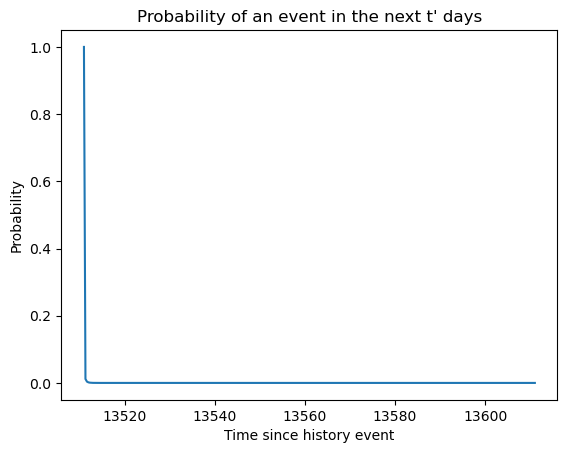

In [14]:
f, ax = plt.subplots()
ax.plot(t_prime_vec, P_vec_california)
ax.set_xlabel("Time since history event")
ax.set_ylabel("Probability")
ax.set_title("Probability of an event in the next t' days")
plt.show()


## Catalog continuation forecast

Run classic ETAS catalog continuation (`simulate_catalog_continuation`) from forecast start time **T**, using only the single history event above as auxiliary catalog. Each recreation keeps the **first forecast event** after **T** (extending the forecast window if needed).

In [15]:
# --- forecast settings (edit these) ---
FORECAST_START = history_event_time  # time T: forecast window starts here
N_RECREATIONS = 1000
N_FORECAST_EVENTS = 1  # keep the first event after T in each recreation
SEED_START = 0

# initial forecast window; extended automatically until N_FORECAST_EVENTS are found
INITIAL_FORECAST_DAYS = 30
MAX_FORECAST_DAYS = 3650
FORECAST_GROWTH_FACTOR = 2.0

# magnitude distribution (Gutenberg–Richter b=1 => beta = ln(10))
BETA_MAIN = np.log(10)
MC = THETA_0["m_c"]

from pathlib import Path
from typing import Optional

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "single_point_history"

# --- persistence ---
# Load only when the canonical CSV for current settings exists (n, seed, resolution, …).
# Older files with different tags are ignored; set FORCE_RECREATE_RECREATIONS = True to always re-simulate.
FORCE_RECREATE_RECREATIONS = False
SAVE_RECREATIONS_OUTPUT = True

# Optional explicit paths (str or Path); None = use canonical name under RECREATIONS_OUTPUT_DIR
SAVED_FORECAST_RECREATIONS_PATH = None
SAVED_GRID_RECREATIONS_PATH = None


def forecast_recreations_path(n_recreations=None, seed_start=None) -> Path:
    n = N_RECREATIONS if n_recreations is None else int(n_recreations)
    seed = SEED_START if seed_start is None else int(seed_start)
    return RECREATIONS_OUTPUT_DIR / f"forecast_recreations_n{n}_seed{seed}.csv"


def grid_recreations_epsilon_path(n_recreations=None, resolution=None) -> Path:
    n = N_RECREATIONS if n_recreations is None else int(n_recreations)
    res = A_H_RESOLUTION if resolution is None else int(resolution)
    return RECREATIONS_OUTPUT_DIR / f"grid_recreations_epsilon_n{n}_res{res}.csv"


def _resolve_saved_csv(explicit_path, canonical_path: Path) -> Optional[Path]:
    """Load only when the file matches current settings (canonical name encodes parameters)."""
    if explicit_path is not None:
        path = Path(explicit_path)
        if not path.is_file():
            raise FileNotFoundError(f"Saved recreations not found: {path}")
        if path.resolve() != canonical_path.resolve():
            print(
                f"Explicit path {path.name} does not match current settings "
                f"({canonical_path.name}); re-simulating."
            )
            return None
        return path
    if canonical_path.is_file():
        return canonical_path
    return None


def _note_stale_saved_csvs(glob_pattern: str, canonical_path: Path) -> None:
    """Hint when older CSVs exist but none match the current parameter tag."""
    if not RECREATIONS_OUTPUT_DIR.is_dir():
        return
    stale = sorted(
        RECREATIONS_OUTPUT_DIR.glob(glob_pattern),
        key=lambda p: p.name,
    )
    stale = [p for p in stale if p.resolve() != canonical_path.resolve()]
    if stale:
        names = ", ".join(p.name for p in stale[:5])
        suffix = " ..." if len(stale) > 5 else ""
        print(
            f"Note: found {len(stale)} saved CSV(s) with other parameters "
            f"({names}{suffix}); need {canonical_path.name} for current settings."
        )


def load_recreations_epsilon_csv(path: Path) -> dict[float, pd.DataFrame]:
    df = pd.read_csv(path)
    if "epsilon" not in df.columns:
        raise ValueError(f"Missing epsilon column in {path}")
    out: dict[float, pd.DataFrame] = {}
    for eps, grp in df.groupby("epsilon"):
        out[float(eps)] = grp.drop(columns="epsilon").reset_index(drop=True)
    return out


In [16]:
# ETAS parameters in the log10 form expected by simulate_catalog_continuation
theta = {
    key: THETA_0[key]
    for key in [
        "log10_mu",
        "log10_k0",
        "a",
        "log10_c",
        "omega",
        "log10_tau",
        "log10_d",
        "gamma",
        "rho",
    ]
}


def _to_naive_utc(ts):
    t = pd.to_datetime(ts, utc=True)
    return t.tz_convert(None)


def simulate_single_event_recreations(
    auxiliary_catalog,
    *,
    auxiliary_start,
    forecast_start,
    polygon,
    theta,
    mc,
    beta_main,
    n_events,
    n_recreations,
    seed_start,
    initial_forecast_days=30,
    max_forecast_days=3650,
    growth_factor=2.0,
):
    """Call simulate_catalog_continuation; keep first n_events after forecast_start."""
    aux_start = _to_naive_utc(auxiliary_start)
    f_start = _to_naive_utc(forecast_start)

    aux = auxiliary_catalog.copy()
    aux["time"] = pd.to_datetime(aux["time"], utc=True).dt.tz_convert(None)

    records = []
    seeds = range(seed_start, seed_start + n_recreations)
    for i, seed in enumerate(
        tqdm(seeds, total=n_recreations, desc="Recreations", unit="run")
    ):
        np.random.seed(int(seed))

        forecast_days = float(initial_forecast_days)
        chosen = None
        while forecast_days <= float(max_forecast_days):
            sim_end = f_start + dt.timedelta(days=forecast_days)

            cont = simulation.simulate_catalog_continuation(
                auxiliary_catalog=aux,
                auxiliary_start=aux_start,
                auxiliary_end=f_start,
                polygon=polygon,
                simulation_end=sim_end,
                parameters=dict(theta),
                mc=float(mc),
                beta_main=beta_main,
                filter_polygon=False,
                magnitude_generator=mc_b_est.simulate_magnitudes,
            )

            cont = cont.copy()
            cont["time"] = pd.to_datetime(cont["time"], utc=True).dt.tz_convert(None)

            forecast_events = cont.loc[cont["time"] > f_start].sort_values("time")
            forecast_events = forecast_events.head(int(n_events))

            if len(forecast_events) >= int(n_events):
                chosen = forecast_events
                break

            forecast_days *= float(growth_factor)

        if chosen is None:
            raise RuntimeError(
                f"Recreation {i} (seed={seed}) did not reach {n_events} event(s) "
                f"within {max_forecast_days} forecast days."
            )

        chosen = chosen[["time", "latitude", "longitude", "magnitude"]].copy()
        chosen["recreation"] = i
        chosen["seed"] = int(seed)
        chosen["event_idx"] = np.arange(len(chosen), dtype=int)
        records.append(chosen)

    if not records:
        return pd.DataFrame(
            columns=[
                "time",
                "latitude",
                "longitude",
                "magnitude",
                "recreation",
                "seed",
                "event_idx",
            ]
        )
    return pd.concat(records, ignore_index=True)


auxiliary_catalog = pd.DataFrame(
    {
        "time": [_to_naive_utc(history_event_time)],
        "latitude": [history_event_y],
        "longitude": [history_event_x],
        "magnitude": [history_event_magnitude],
        "xi_plus_1": [1.0],
    }
)
auxiliary_start = auxiliary_catalog["time"].min()
forecast_start = _to_naive_utc(FORECAST_START)

_forecast_canonical = forecast_recreations_path()
_forecast_load_path = None if FORCE_RECREATE_RECREATIONS else _resolve_saved_csv(
    SAVED_FORECAST_RECREATIONS_PATH,
    _forecast_canonical,
)

_forecast_loaded = False

if not FORCE_RECREATE_RECREATIONS and _forecast_load_path is not None:
    _candidate = pd.read_csv(_forecast_load_path, parse_dates=["time"])
    n_rec_ok = _candidate["recreation"].nunique() == N_RECREATIONS
    n_evt_ok = (
        _candidate.groupby("recreation")["event_idx"].max().add(1) >= N_FORECAST_EVENTS
    ).all()
    if n_rec_ok and n_evt_ok:
        print(f"Loading forecast_recreations from {_forecast_load_path}")
        forecast_recreations = _candidate
        _forecast_loaded = True
    else:
        print(
            f"Saved forecast_recreations shape does not match "
            f"n={N_RECREATIONS}, events={N_FORECAST_EVENTS}; re-simulating."
        )

if not _forecast_loaded:
    if FORCE_RECREATE_RECREATIONS:
        print("FORCE_RECREATE_RECREATIONS=True: simulating classic ETAS recreations...")
    else:
        _note_stale_saved_csvs(
            "forecast_recreations_n*_seed*.csv",
            _forecast_canonical,
        )
        if _forecast_load_path is None:
            print(
                f"No saved forecast_recreations for current settings "
                f"({_forecast_canonical.name}); simulating..."
            )
    forecast_recreations = simulate_single_event_recreations(
        auxiliary_catalog,
        auxiliary_start=auxiliary_start,
        forecast_start=forecast_start,
        polygon=polygon,
        theta=theta,
        mc=MC,
        beta_main=BETA_MAIN,
        n_events=N_FORECAST_EVENTS,
        n_recreations=N_RECREATIONS,
        seed_start=SEED_START,
        initial_forecast_days=INITIAL_FORECAST_DAYS,
        max_forecast_days=MAX_FORECAST_DAYS,
        growth_factor=FORECAST_GROWTH_FACTOR,
    )

print(
    f"Forecast from T={forecast_start}: "
    f"{len(forecast_recreations)} event(s) "
    f"({forecast_recreations['recreation'].nunique()} recreations x {N_FORECAST_EVENTS})"
)

if SAVE_RECREATIONS_OUTPUT and not _forecast_loaded:
    RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    forecast_recreations.to_csv(_forecast_canonical, index=False)
    print(f"Saved forecast_recreations -> {_forecast_canonical}")

forecast_recreations



Loading forecast_recreations from /home/neriberman/Repos/etas/outputs/single_point_history/forecast_recreations_n1000_seed0.csv
Forecast from T=2006-12-29 00:00:00: 1000 event(s) (1000 recreations x 1)


,time,latitude,longitude,magnitude,recreation,seed,event_idx
0,2006-12-29 00:04:33.384782147,33.640841,-116.390571,4.446771,0,0,0
1,2006-12-29 00:01:27.373472342,33.606112,-116.410896,4.255075,1,1,0
2,2006-12-29 00:01:29.696643390,33.609112,-116.404300,4.140123,2,2,0
3,2006-12-29 00:02:25.783504304,33.614555,-116.365436,4.030258,3,3,0
4,2006-12-29 01:14:22.885729140,33.598656,-116.409180,3.517818,4,4,0
...,...,...,...,...,...,...,...
995,2006-12-29 00:43:01.613004968,33.579169,-116.383727,3.819263,995,995,0
996,2006-12-29 00:02:26.394538047,33.599709,-116.411527,3.733496,996,996,0
997,2006-12-29 00:08:18.770315478,33.644308,-116.373536,3.925489,997,997,0
998,2006-12-29 00:13:22.786741801,33.621556,-116.412113,4.930851,998,998,0


2026-06-12 15:52:55,832 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=8.0.
2026-06-12 15:52:55,833 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-12 15:52:55,834 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-12 15:52:55,834 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu San

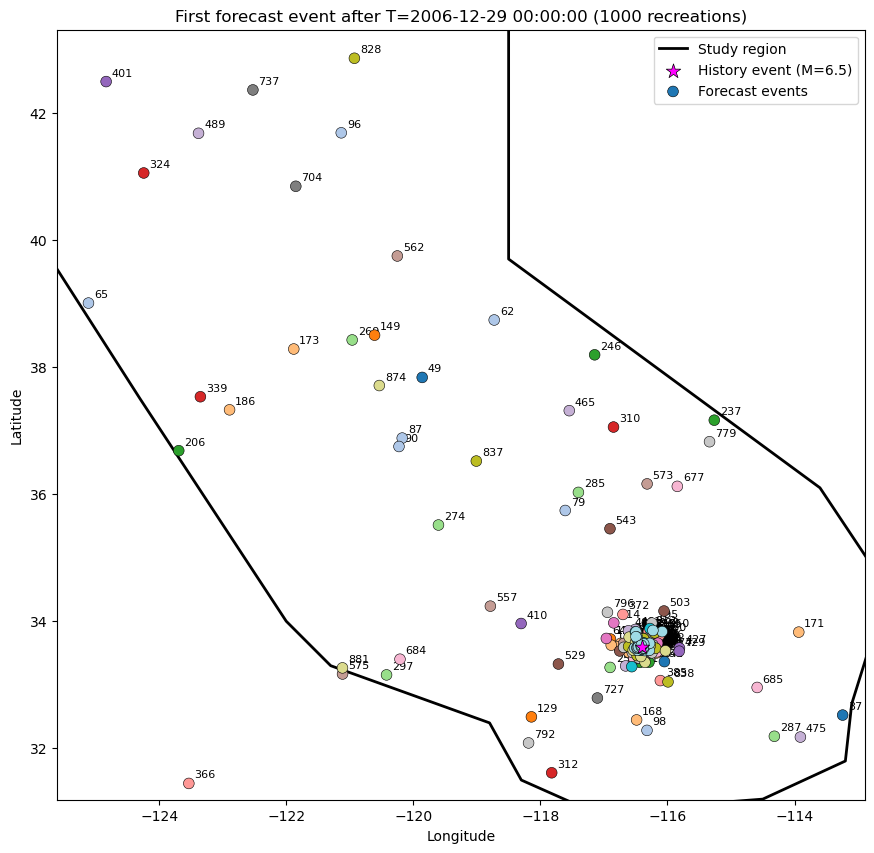

In [17]:
fig_forecast, ax = plt.subplots(figsize=(12, 10))

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")

ax.scatter(
    [history_event_x],
    [history_event_y],
    s=120,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

ax.scatter(
    forecast_recreations["longitude"],
    forecast_recreations["latitude"],
    s=60,
    c=forecast_recreations["recreation"],
    cmap="tab20",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    label="Forecast events",
)

for _, row in forecast_recreations.iterrows():
    ax.annotate(
        str(int(row["recreation"])),
        (row["longitude"], row["latitude"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"First forecast event after T={FORECAST_START} ({N_RECREATIONS} recreations)")
ax.set_aspect("equal")
ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


Binned 1000 simulated event(s) from 1000 recreations over 30 day forecast window.
Non-zero cells: 58 / 494; max count in one cell: 854
2026-06-12 15:52:59,224 - DEBUG - locator: <matplotlib.ticker.LogLocator object at 0x7661de1156d0>
2026-06-12 15:52:59,264 - DEBUG - vmin 3.896731370250758e-07 vmax 0.0004317821198702578
2026-06-12 15:52:59,264 - DEBUG - ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02])
2026-06-12 15:52:59,268 - DEBUG - vmin 3.896731370250758e-07 vmax 0.0004317821198702578
2026-06-12 15:52:59,268 - DEBUG - ticklocs array([2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02,

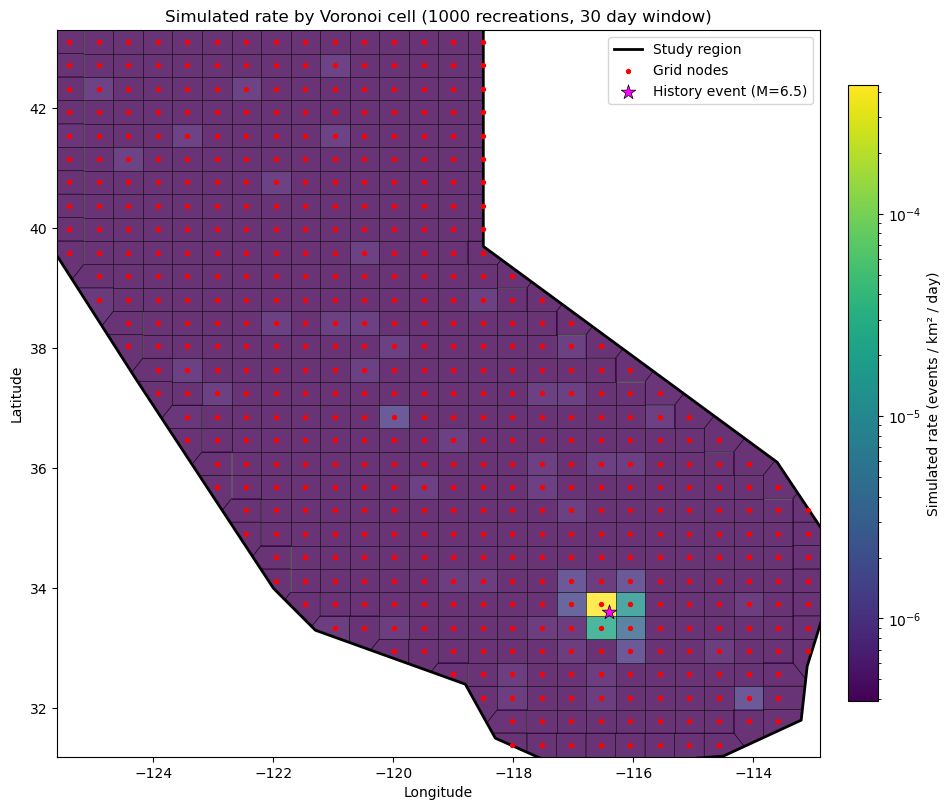

In [18]:
# Empirical rate per Voronoi cell from catalog-continuation recreations


def _polygon_parts(geom):
    if geom.is_empty:
        return
    if geom.geom_type == "Polygon":
        yield geom
    elif geom.geom_type == "MultiPolygon":
        yield from geom.geoms
    elif geom.geom_type == "GeometryCollection":
        for g in geom.geoms:
            yield from _polygon_parts(g)


def calculate_areas_km2(polygons):
    geod = pyproj.Geod(ellps="WGS84")
    areas = []
    for poly in polygons:
        if poly.is_empty:
            areas.append(0.0)
        else:
            area_m2, _ = geod.geometry_area_perimeter(poly)
            areas.append(abs(area_m2) / 1e6)
    return areas


sim_events = (
    forecast_recreations.sort_values(["recreation", "time"])
    .groupby("recreation", as_index=False)
    .head(N_FORECAST_EVENTS)
)

counts_per_cell = np.zeros(len(ordered_cells), dtype=int)
for lon, lat in zip(sim_events["longitude"].to_numpy(), sim_events["latitude"].to_numpy()):
    p = Point(lon, lat)
    for j, cell in enumerate(ordered_cells):
        if cell.contains(p):
            counts_per_cell[j] += 1
            break

cell_areas_km2 = np.array(calculate_areas_km2(ordered_cells), dtype=float)
forecast_days = float(INITIAL_FORECAST_DAYS)
n_realizations = int(sim_events["recreation"].nunique())

# events / km² / day
sim_rate_per_cell = np.zeros(len(ordered_cells), dtype=float)
valid = cell_areas_km2 > 0
sim_rate_per_cell[valid] = counts_per_cell[valid] / (
    # n_realizations * forecast_days * cell_areas_km2[valid]
    n_realizations * cell_areas_km2[valid]
)

print(
    f"Binned {len(sim_events)} simulated event(s) from {n_realizations} recreations "
    f"over {forecast_days:.0f} day forecast window."
)
print(
    f"Non-zero cells: {(counts_per_cell > 0).sum()} / {len(ordered_cells)}; "
    f"max count in one cell: {counts_per_cell.max()}"
)

fig_sim_rate, ax = plt.subplots(figsize=(12, 10))
positive_rates = sim_rate_per_cell[sim_rate_per_cell > 0]
rate_vmin = float(positive_rates.min()) if positive_rates.size else 1e-20
rate_vmax = float(max(sim_rate_per_cell.max(), rate_vmin * 10))
plot_rate = np.maximum(sim_rate_per_cell, rate_vmin)
norm = colors.LogNorm(vmin=rate_vmin, vmax=rate_vmax)
cmap = plt.cm.viridis

for j, cell in enumerate(ordered_cells):
    color = cmap(norm(plot_rate[j]))
    for part in _polygon_parts(cell):
        xy = np.asarray(part.exterior.coords)
        ax.add_patch(
            mpatches.Polygon(
                xy,
                closed=True,
                facecolor=color,
                edgecolor="k",
                alpha=0.8,
                linewidth=0.4,
            )
        )

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")
ax.scatter(lon_flat, lat_flat, s=8, c="red", zorder=5, label="Grid nodes")
ax.scatter(
    [history_event_x],
    [history_event_y],
    s=120,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.03)
cbar.set_label("Simulated rate (events / km² / day)")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Simulated rate by Voronoi cell "
    f"({n_realizations} recreations, {forecast_days:.0f} day window)"
)
ax.set_aspect("equal")
ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


Recreations: 1000, first events (event_idx=0): 1000
Time to first event (days): median=0.006, 5-95%=0.000-0.173
2026-06-12 15:52:59,517 - DEBUG - vmin 5.0792738676193556e-06 vmax 3.7041895673466083
2026-06-12 15:52:59,518 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02])
2026-06-12 15:52:59,522 - DEBUG - vmin 5.0792738676193556e-06 vmax 3.7041895673466083
2026-06-12 15:52:59,523 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00,

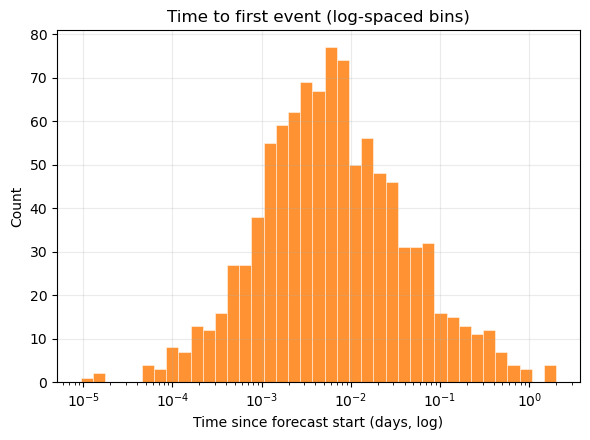

count    1000.000000
mean        0.040286
std         0.144411
min         0.000009
25%         0.001771
50%         0.005688
75%         0.020616
max         1.985531
dtype: float64

In [19]:
# Time to first forecast event — same style as grid_recreations_point_process.ipynb Step 5
FIRST_EVENT_IDX = 0
SECONDS_PER_DAY = 86400.0

t0 = pd.to_datetime(FORECAST_START, utc=True)

df_rec = forecast_recreations.loc[
    forecast_recreations["event_idx"] == FIRST_EVENT_IDX
].copy()
df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
df_rec = df_rec.sort_values(["recreation", "time"]).reset_index(drop=True)
df_rec["t_from_start_days"] = (df_rec["time"] - t0).dt.total_seconds() / SECONDS_PER_DAY

dt_to_first = df_rec.loc[df_rec["t_from_start_days"] > 0, "t_from_start_days"].to_numpy()

print(
    f"Recreations: {df_rec['recreation'].nunique()}, "
    f"first events (event_idx={FIRST_EVENT_IDX}): {len(df_rec)}"
)
if np.any(dt_to_first > 0):
    q = np.quantile(dt_to_first, [0.05, 0.5, 0.95])
    print(f"Time to first event (days): median={q[1]:.3f}, 5-95%={q[0]:.3f}-{q[2]:.3f}")

fig_delta_t, ax = plt.subplots(figsize=(6, 4.5))
if len(dt_to_first):
    bins_dt = np.logspace(
        np.log10(dt_to_first.min()),
        np.log10(dt_to_first.max() * 1.01),
        40,
    )
    ax.hist(
        dt_to_first,
        bins=bins_dt,
        color="tab:orange",
        alpha=0.85,
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_xscale("log")
ax.set_xlabel("Time since forecast start (days, log)")
ax.set_ylabel("Count")
ax.set_title("Time to first event (log-spaced bins)")
ax.grid(True, alpha=0.25)

fig_delta_t.tight_layout()
plt.show()

pd.Series(dt_to_first).describe()


Recreations: 1000, first events (event_idx=0): 1000
Time to first event (days): median=0.006, 5-95%=0.000-0.173


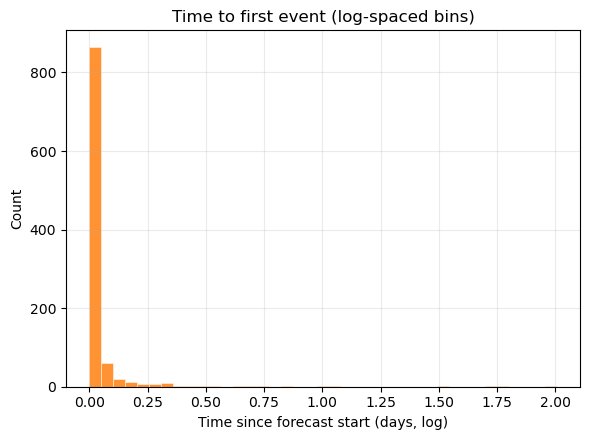

count    1000.000000
mean        0.040286
std         0.144411
min         0.000009
25%         0.001771
50%         0.005688
75%         0.020616
max         1.985531
dtype: float64

In [34]:
# Time to first forecast event — same style as grid_recreations_point_process.ipynb Step 5
FIRST_EVENT_IDX = 0
SECONDS_PER_DAY = 86400.0

t0 = pd.to_datetime(FORECAST_START, utc=True)

df_rec = forecast_recreations.loc[
    forecast_recreations["event_idx"] == FIRST_EVENT_IDX
].copy()
df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
df_rec = df_rec.sort_values(["recreation", "time"]).reset_index(drop=True)
df_rec["t_from_start_days"] = (df_rec["time"] - t0).dt.total_seconds() / SECONDS_PER_DAY

dt_to_first = df_rec.loc[df_rec["t_from_start_days"] > 0, "t_from_start_days"].to_numpy()

print(
    f"Recreations: {df_rec['recreation'].nunique()}, "
    f"first events (event_idx={FIRST_EVENT_IDX}): {len(df_rec)}"
)
if np.any(dt_to_first > 0):
    q = np.quantile(dt_to_first, [0.05, 0.5, 0.95])
    print(f"Time to first event (days): median={q[1]:.3f}, 5-95%={q[0]:.3f}-{q[2]:.3f}")

fig_delta_t, ax = plt.subplots(figsize=(6, 4.5))
bins_dt = np.linspace(
    dt_to_first.min(),
    dt_to_first.max() * 1.01,
    40,
)
ax.hist(
    dt_to_first,
    bins=bins_dt,
    color="tab:orange",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)
# ax.set_xscale("log")
ax.set_xlabel("Time since forecast start (days, log)")
ax.set_ylabel("Count")
ax.set_title("Time to first event (log-spaced bins)")
ax.grid(True, alpha=0.25)

fig_delta_t.tight_layout()
plt.show()

pd.Series(dt_to_first).describe()


Text(0.5, 1.0, 'CDF of time to first event')

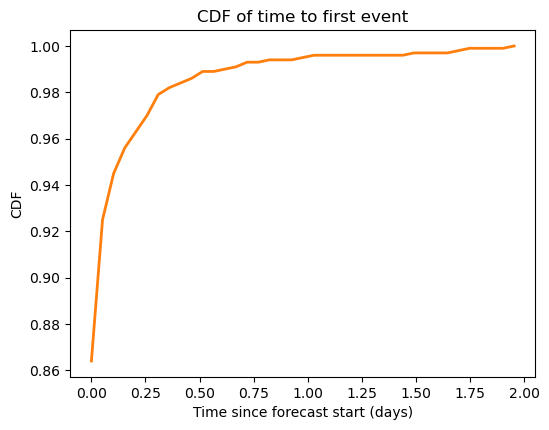

In [20]:
bins_dt = np.linspace(
        dt_to_first.min(),
        dt_to_first.max() * 1.01,
        40,
    )
    
hist, bins = np.histogram(
    dt_to_first,
    bins=bins_dt,
)

# CDF
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

fig_cdf, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(bins[:-1], cdf, color="tab:orange", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("CDF")
ax.set_title("CDF of time to first event")


# Simulate times on the grid

In [21]:
# def rhs(t_prime, t, H, params):
#     t_h = H['t']
#     rhs = np.exp(-params['mu'] * (t_prime - t)) * np.exp(
#         A_h(H['x'], H['y'], H, params) * (
#             np.exp(params["c"]/params["tau"]) / params['tau']**(-params['omega'])
#             ) * (
#                 unreg_gamma(-params['omega'], (params['c'] + t_prime - t_h) / params['tau']) -
#                 unreg_gamma(-params['omega'], (params['c'] + t - t_h) / params['tau'])
#                 )
#         )
#     return rhs

def solve_next_event_time_per_cell(U: float, t: float, target_polygon: Polygon, H: History, params: EtasParams, resolution: int = 50):
    """
    Solves for t_prime using the log-space RHS and Brent's method.
    """
    target_val = np.log(U)
    
    def residual(t_prime):
        return log_rhs(t_prime, t, target_polygon, H, params, resolution) - target_val

    # Dynamic bracketing
    upper_bound = t + 1.0
    while residual(upper_bound) > 0:
        upper_bound = t + (upper_bound - t) * 2.0
        
    sol = root_scalar(residual, bracket=[t, upper_bound], method='brentq')
    return sol.root 


In [22]:
## create a single realization of the point process
def create_single_realization(
    rng: np.random.RandomState,
    history_dict: History,
    ordered_cells: list[Polygon],
    lon_flat: np.ndarray,
    lat_flat: np.ndarray,
    epsilon: float,
    resolution: int = 50,
) -> dict:
    ordered_event_times = []
    for cell in ordered_cells:
        U = rng.uniform()
        t_prime = solve_next_event_time_per_cell(
            U, history_dict["t"] + epsilon, cell, history_dict, THETA_0, resolution
        )
        ordered_event_times.append(t_prime)

    min_index = int(np.argmin(ordered_event_times))
    min_event_time = ordered_event_times[min_index]
    magnitude = mc_b_est.simulate_magnitudes(1, BETA_MAIN, MC)[0]

    return {
        "time": min_event_time,
        "magnitude": magnitude,
        "longitude": float(lon_flat[min_index]),
        "latitude": float(lat_flat[min_index]),
        "cell_idx": min_index,
    }


In [23]:
# n_recreations = N_RECREATIONS
# # n_recreations = 20
# RESOLUTION = 50
# rngseed = 1905
# recreations_df = pd.DataFrame()
# rng = np.random.RandomState(rngseed)
# for i in tqdm(range(n_recreations)):
#     # U = rng.uniform()
#     event_dict = create_single_realization(rng, history_dict, ordered_cells, lon_flat, lat_flat, RESOLUTION)
#     recreations_df = pd.concat([recreations_df, pd.DataFrame([event_dict])], ignore_index=True)
#     rngseed += 1
#     rng = np.random.RandomState(rngseed)
# recreations_df


In [24]:
# epsilon_vec = np.concatenate([np.array([0]), 10**np.arange(-4, 4, 2, dtype=float)])
epsilon_vec = np.array([0])
n_recreations = N_RECREATIONS
# n_recreations = 100

_grid_canonical = grid_recreations_epsilon_path(n_recreations, A_H_RESOLUTION)
_grid_load_path = None if FORCE_RECREATE_RECREATIONS else _resolve_saved_csv(
    SAVED_GRID_RECREATIONS_PATH,
    _grid_canonical,
)

_grid_loaded = False
recreations_epsilon = {}
wanted_eps = [float(e) for e in epsilon_vec]

if not FORCE_RECREATE_RECREATIONS and _grid_load_path is not None:
    _candidate = load_recreations_epsilon_csv(_grid_load_path)
    loaded_eps = sorted(_candidate.keys())
    nrow_ok = all(len(_candidate[e]) == n_recreations for e in _candidate)
    if loaded_eps == wanted_eps and nrow_ok:
        print(f"Loading recreations_epsilon from {_grid_load_path}")
        recreations_epsilon = _candidate
        _grid_loaded = True
    elif loaded_eps != wanted_eps:
        print(
            f"Saved epsilons {loaded_eps} != epsilon_vec {wanted_eps}; re-simulating."
        )
    else:
        print(
            f"Saved row count != n_recreations={n_recreations}; re-simulating."
        )

if not _grid_loaded:
    if FORCE_RECREATE_RECREATIONS:
        print("FORCE_RECREATE_RECREATIONS=True: simulating grid point-process recreations...")
    else:
        _note_stale_saved_csvs(
            "grid_recreations_epsilon_n*_res*.csv",
            _grid_canonical,
        )
        if _grid_load_path is None:
            print(
                f"No saved recreations_epsilon for current settings "
                f"({_grid_canonical.name}); simulating..."
            )

    epsilon_pbar = tqdm(
        epsilon_vec,
        desc="Epsilon",
        position=0,
        unit="eps",
        dynamic_ncols=True,
    )

    for epsilon in epsilon_pbar:
        epsilon_pbar.set_postfix_str(f"ε={epsilon:g}")

        rngseed = 1905
        records = []
        rng = np.random.RandomState(rngseed)

        for i in tqdm(
            range(n_recreations),
            desc="Recreations",
            position=1,
            leave=False,
            unit="run",
            dynamic_ncols=True,
        ):
            event_dict = create_single_realization(
                rng,
                history_dict,
                ordered_cells,
                lon_flat,
                lat_flat,
                epsilon,
                A_H_RESOLUTION,
            )
            records.append(event_dict)
            rngseed += 1
            rng = np.random.RandomState(rngseed)

        recreations_epsilon[epsilon] = pd.DataFrame.from_records(records)

if SAVE_RECREATIONS_OUTPUT and not _grid_loaded:
    RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    recreations_epsilon_df = pd.concat(
        [df.assign(epsilon=float(eps)) for eps, df in recreations_epsilon.items()],
        ignore_index=True,
    )
    recreations_epsilon_df.to_csv(_grid_canonical, index=False)
    print(f"Saved recreations_epsilon -> {_grid_canonical}")

recreations_epsilon



Loading recreations_epsilon from /home/neriberman/Repos/etas/outputs/single_point_history/grid_recreations_epsilon_n1000_res40.csv


{0.0:              time  magnitude   longitude   latitude  cell_idx
 0    13511.004883   4.891975 -116.540741  33.734375       390
 1    13511.124064   3.796973 -116.540741  33.734375       390
 2    13511.015040   3.763622 -116.540741  33.734375       390
 3    13511.010511   3.675919 -116.540741  33.734375       390
 4    13511.000693   3.562094 -116.540741  33.734375       390
 ..            ...        ...         ...        ...       ...
 995  13511.018547   3.670296 -116.540741  33.734375       390
 996  13511.000098   4.226325 -116.540741  33.734375       390
 997  13511.175237   3.585974 -116.540741  33.343750       389
 998  13511.007273   3.754304 -116.540741  33.734375       390
 999  13511.139141   4.455859 -116.540741  33.734375       390
 
 [1000 rows x 5 columns]}

In [25]:
# Re-run this cell to write CSVs from in-memory results (no re-simulation).
if "RECREATIONS_OUTPUT_DIR" not in globals():
    from pathlib import Path

    REPO_ROOT = Path.cwd().resolve()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "single_point_history"
    SAVE_RECREATIONS_OUTPUT = True

if not SAVE_RECREATIONS_OUTPUT:
    print("SAVE_RECREATIONS_OUTPUT is False; nothing written.")
else:
    RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    saved = []

    if "forecast_recreations" in globals() and len(forecast_recreations):
        path = forecast_recreations_path()
        forecast_recreations.to_csv(path, index=False)
        saved.append(str(path))

    if "recreations_epsilon" in globals() and recreations_epsilon:
        n_rec = len(next(iter(recreations_epsilon.values())))
        path = grid_recreations_epsilon_path(n_rec, A_H_RESOLUTION)
        recreations_epsilon_df = pd.concat(
            [df.assign(epsilon=float(eps)) for eps, df in recreations_epsilon.items()],
            ignore_index=True,
        )
        recreations_epsilon_df.to_csv(path, index=False)
        saved.append(str(path))

    if saved:
        print("Saved:")
        for path in saved:
            print(f"  {path}")
    else:
        print("No forecast_recreations or recreations_epsilon in memory.")


Saved:
  /home/neriberman/Repos/etas/outputs/single_point_history/forecast_recreations_n1000_seed0.csv
  /home/neriberman/Repos/etas/outputs/single_point_history/grid_recreations_epsilon_n1000_res40.csv


ε=0: binned 1000 events; non-zero cells 102/494; max count 791
2026-06-12 15:53:00,361 - DEBUG - locator: <matplotlib.ticker.LogLocator object at 0x7661dd9a4550>
2026-06-12 15:53:00,389 - DEBUG - vmin 3.389111106479038e-07 vmax 0.0003999293405355667
2026-06-12 15:53:00,389 - DEBUG - ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02])
2026-06-12 15:53:00,392 - DEBUG - vmin 3.389111106479038e-07 vmax 0.0003999293405355667
2026-06-12 15:53:00,393 - DEBUG - ticklocs array([2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02])
2026-06-12 15:

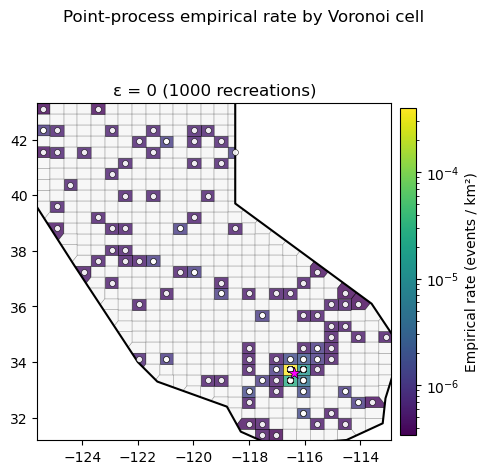

In [26]:
# Empirical rate per Voronoi cell for each epsilon in recreations_epsilon

if "_polygon_parts" not in globals():
    def _polygon_parts(geom):
        if geom.is_empty:
            return
        if geom.geom_type == "Polygon":
            yield geom
        elif geom.geom_type == "MultiPolygon":
            yield from geom.geoms
        elif geom.geom_type == "GeometryCollection":
            for g in geom.geoms:
                yield from _polygon_parts(g)

if "calculate_areas_km2" not in globals():
    def calculate_areas_km2(polygons):
        geod = pyproj.Geod(ellps="WGS84")
        areas = []
        for poly in polygons:
            if poly.is_empty:
                areas.append(0.0)
            else:
                area_m2, _ = geod.geometry_area_perimeter(poly)
                areas.append(abs(area_m2) / 1e6)
        return areas

if "cell_areas_km2" not in globals():
    cell_areas_km2 = np.array(calculate_areas_km2(ordered_cells), dtype=float)

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
xlim = (np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
ylim = (np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)


def _bin_events_to_cells(pp_events):
    counts = np.zeros(len(ordered_cells), dtype=int)
    if "cell_idx" in pp_events.columns:
        for idx in pp_events["cell_idx"].astype(int).to_numpy():
            counts[idx] += 1
    else:
        for lon, lat in zip(pp_events["longitude"].to_numpy(), pp_events["latitude"].to_numpy()):
            j = int(np.argmin((lon_flat - lon) ** 2 + (lat_flat - lat) ** 2))
            counts[j] += 1
    return counts


def _counts_to_rate(counts, n_realizations):
    rate = np.zeros(len(ordered_cells), dtype=float)
    valid = cell_areas_km2 > 0
    rate[valid] = counts[valid] / (n_realizations * cell_areas_km2[valid])
    return rate


def _draw_rate_map(ax, pp_events, counts, rate, *, title):
    occupied = counts > 0
    if not occupied.any():
        ax.text(0.5, 0.5, "No events binned", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    plot_rate = np.maximum(rate, rate_vmin)
    for j, cell in enumerate(ordered_cells):
        if occupied[j]:
            facecolor = cmap(norm(plot_rate[j]))
            edge_lw = 0.4
            alpha = 0.8
        else:
            facecolor = "#f0f0f0"
            edge_lw = 0.2
            alpha = 0.5
        for part in _polygon_parts(cell):
            xy = np.asarray(part.exterior.coords)
            ax.add_patch(
                mpatches.Polygon(
                    xy,
                    closed=True,
                    facecolor=facecolor,
                    edgecolor="k",
                    alpha=alpha,
                    linewidth=edge_lw,
                )
            )

    ax.plot(lon_poly, lat_poly, color="black", linewidth=1.5)
    ax.scatter(
        pp_events["longitude"],
        pp_events["latitude"],
        s=18,
        c="white",
        edgecolors="black",
        linewidths=0.4,
        alpha=0.9,
        zorder=7,
    )
    ax.scatter(
        [history_event_x],
        [history_event_y],
        s=80,
        c="magenta",
        marker="*",
        edgecolors="black",
        linewidths=0.5,
        zorder=8,
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)


epsilons = list(epsilon_vec) if "epsilon_vec" in globals() else sorted(recreations_epsilon.keys(), key=float)
epsilons = [eps for eps in epsilons if eps in recreations_epsilon]
if not epsilons:
    epsilons = sorted(recreations_epsilon.keys(), key=float)

rates_by_eps = {}
all_positive = []
for eps in epsilons:
    pp_events = recreations_epsilon[eps]
    counts = _bin_events_to_cells(pp_events)
    n_realizations_pp = len(pp_events)
    rate_per_cell = _counts_to_rate(counts, n_realizations_pp)
    rates_by_eps[eps] = (pp_events, counts, rate_per_cell, n_realizations_pp)
    positive = rate_per_cell[counts > 0]
    if positive.size:
        all_positive.append(positive)

if not all_positive:
    raise ValueError("No events were assigned to any Voronoi cell.")

rate_vmin = float(np.min(np.concatenate(all_positive)))
rate_vmax = float(np.max(np.concatenate(all_positive)))
if rate_vmin == rate_vmax:
    rate_vmax = rate_vmin * 10.0
norm = colors.LogNorm(vmin=rate_vmin, vmax=rate_vmax)
cmap = plt.cm.viridis

n_eps = len(epsilons)
ncols = min(3, n_eps)
nrows = int(np.ceil(n_eps / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), squeeze=False)

for idx, eps in enumerate(epsilons):
    ax = axes[idx // ncols, idx % ncols]
    pp_events, counts, rate_per_cell, n_realizations_pp = rates_by_eps[eps]
    _draw_rate_map(
        ax,
        pp_events,
        counts,
        rate_per_cell,
        title=f"ε = {eps:g} ({n_realizations_pp} recreations)",
    )
    print(
        f"ε={eps:g}: binned {len(pp_events)} events; "
        f"non-zero cells {(counts > 0).sum()}/{len(ordered_cells)}; "
        f"max count {counts.max()}"
    )

for idx in range(n_eps, nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

fig.subplots_adjust(right=0.9, hspace=0.25, wspace=0.15)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
cbar.set_label("Empirical rate (events / km²)")
fig.suptitle("Point-process empirical rate by Voronoi cell", y=1.02)
plt.show()


### Spatial rate comparison by Voronoi cell

Side-by-side maps at \(T_h + \varepsilon\) (default: first value in `epsilon_vec`):

- **Classic ETAS (C)**: empirical density of first simulated event per recreation
- **Grid point process (B)**: empirical density from `recreations_epsilon`
- **Analytical (A)**: \(\lambda(x,y,t)=\mu + a_h(x,y)\,g(t)\) at each grid node / cell


2026-06-12 15:53:03,024 - DEBUG - locator: <matplotlib.ticker.LogLocator object at 0x7661dc165150>
2026-06-12 15:53:03,061 - DEBUG - vmin 3.389111106479038e-07 vmax 0.0074903115075731245
2026-06-12 15:53:03,061 - DEBUG - ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01])
2026-06-12 15:53:03,065 - DEBUG - vmin 3.389111106479038e-07 vmax 0.0074903115075731245
2026-06-12 15:53:03,065 - DEBUG - ticklocs array([2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01]

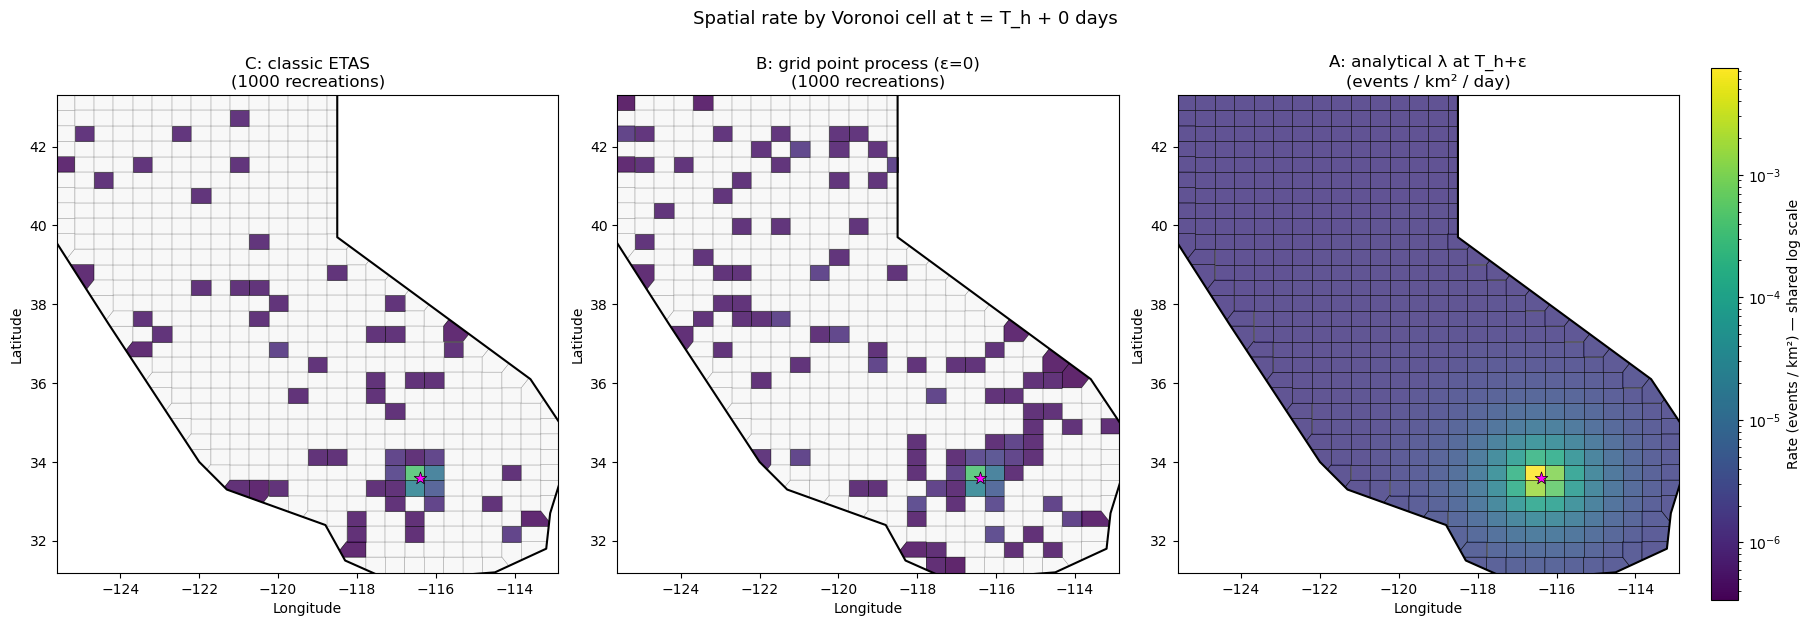

,method,n_recreations,nonzero_cells,max_rate
0,classic ETAS,1000.0,58,0.000432
1,grid point process,1000.0,102,0.000400
2,analytical,NaN,494,0.007490


In [27]:
# Side-by-side: classic sim vs grid PP vs analytical rate by Voronoi cell
if "_polygon_parts" not in globals():
    def _polygon_parts(geom):
        if geom.is_empty:
            return
        if geom.geom_type == "Polygon":
            yield geom
        elif geom.geom_type == "MultiPolygon":
            yield from geom.geoms
        elif geom.geom_type == "GeometryCollection":
            for g in geom.geoms:
                yield from _polygon_parts(g)

if "calculate_areas_km2" not in globals():
    def calculate_areas_km2(polygons):
        geod = pyproj.Geod(ellps="WGS84")
        areas = []
        for poly in polygons:
            if poly.is_empty:
                areas.append(0.0)
            else:
                area_m2, _ = geod.geometry_area_perimeter(poly)
                areas.append(abs(area_m2) / 1e6)
        return areas

if "cell_areas_km2" not in globals():
    cell_areas_km2 = np.array(calculate_areas_km2(ordered_cells), dtype=float)

poly_coords = np.asarray(polygon.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
xlim = (np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
ylim = (np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)

eps_compare = float(epsilon_vec[0]) if "epsilon_vec" in globals() else 0.0
history_t_days = float(history_dict["t"])
t_eval_rate = history_t_days + eps_compare


def _bin_lonlat_to_cells(lons, lats):
    counts = np.zeros(len(ordered_cells), dtype=int)
    for lon, lat in zip(np.asarray(lons, dtype=float), np.asarray(lats, dtype=float)):
        p = Point(lon, lat)
        for j, cell in enumerate(ordered_cells):
            if cell.contains(p):
                counts[j] += 1
                break
    return counts


def _empirical_rate_from_counts(counts, n_realizations):
    rate = np.zeros(len(ordered_cells), dtype=float)
    valid = cell_areas_km2 > 0
    rate[valid] = counts[valid] / (float(n_realizations) * cell_areas_km2[valid])
    return rate


# --- C: classic ETAS first-event locations ---
sim_events = (
    forecast_recreations.sort_values(["recreation", "time"])
    .groupby("recreation", as_index=False)
    .head(N_FORECAST_EVENTS)
)
sim_counts = _bin_lonlat_to_cells(
    sim_events["longitude"].to_numpy(), sim_events["latitude"].to_numpy()
)
n_sim = int(sim_events["recreation"].nunique())
sim_rate_per_cell = _empirical_rate_from_counts(sim_counts, n_sim)

# --- B: grid point-process recreations ---
if eps_compare not in recreations_epsilon:
    raise KeyError(f"epsilon {eps_compare} not in recreations_epsilon; run grid recreations first.")
pp_events = recreations_epsilon[eps_compare]
if "cell_idx" in pp_events.columns:
    pp_counts = np.zeros(len(ordered_cells), dtype=int)
    for idx in pp_events["cell_idx"].astype(int).to_numpy():
        pp_counts[idx] += 1
else:
    pp_counts = _bin_lonlat_to_cells(
        pp_events["longitude"].to_numpy(), pp_events["latitude"].to_numpy()
    )
n_pp = len(pp_events)
pp_rate_per_cell = _empirical_rate_from_counts(pp_counts, n_pp)

# --- A: analytical intensity at grid nodes (one per Voronoi cell) ---
analytical_rate_per_cell = etas_rate_at_xy(
    lon_flat, lat_flat, t_eval_rate, history_dict, THETA_0
)
analytical_rate_per_cell = np.asarray(analytical_rate_per_cell, dtype=float)


def _draw_rate_panel(ax, rate_per_cell, *, title, counts=None):
    """Fill Voronoi cells with log-scaled rate; optional counts mask for empirical maps."""
    if counts is None:
        occupied = rate_per_cell > 0
    else:
        occupied = counts > 0

    plot_vals = np.maximum(rate_per_cell, rate_vmin)
    for j, cell in enumerate(ordered_cells):
        if occupied[j]:
            facecolor = cmap(norm(plot_vals[j]))
            alpha = 0.85
            lw = 0.4
        else:
            facecolor = "#f0f0f0"
            alpha = 0.45
            lw = 0.2
        for part in _polygon_parts(cell):
            xy = np.asarray(part.exterior.coords)
            ax.add_patch(
                mpatches.Polygon(
                    xy,
                    closed=True,
                    facecolor=facecolor,
                    edgecolor="k",
                    alpha=alpha,
                    linewidth=lw,
                )
            )

    ax.plot(lon_poly, lat_poly, color="black", linewidth=1.5)
    ax.scatter(
        [history_event_x],
        [history_event_y],
        s=90,
        c="magenta",
        marker="*",
        edgecolors="black",
        linewidths=0.5,
        zorder=8,
    )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")


positive_all = np.concatenate(
    [
        sim_rate_per_cell[sim_rate_per_cell > 0],
        pp_rate_per_cell[pp_rate_per_cell > 0],
        analytical_rate_per_cell[analytical_rate_per_cell > 0],
    ]
)
if positive_all.size == 0:
    raise ValueError("All rate maps are zero; check upstream recreations.")
rate_vmin = float(positive_all.min())
rate_vmax = float(positive_all.max())
if rate_vmin == rate_vmax:
    rate_vmax = rate_vmin * 10.0
norm = colors.LogNorm(vmin=rate_vmin, vmax=rate_vmax)
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

_draw_rate_panel(
    axes[0],
    sim_rate_per_cell,
    title=f"C: classic ETAS\n({n_sim} recreations)",
    counts=sim_counts,
)
_draw_rate_panel(
    axes[1],
    pp_rate_per_cell,
    title=f"B: grid point process (ε={eps_compare:g})\n({n_pp} recreations)",
    counts=pp_counts,
)
_draw_rate_panel(
    axes[2],
    analytical_rate_per_cell,
    title=f"A: analytical λ at T_h+ε\n(events / km² / day)",
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.9, pad=0.02)
cbar.set_label("Rate (events / km²) — shared log scale")

fig.suptitle(
    f"Spatial rate by Voronoi cell at t = T_h + {eps_compare:g} days",
    y=1.04,
    fontsize=13,
)
plt.show()

pd.DataFrame(
    {
        "method": ["classic ETAS", "grid point process", "analytical"],
        "n_recreations": [n_sim, n_pp, np.nan],
        "nonzero_cells": [
            int((sim_counts > 0).sum()),
            int((pp_counts > 0).sum()),
            int((analytical_rate_per_cell > 0).sum()),
        ],
        "max_rate": [
            float(sim_rate_per_cell.max()),
            float(pp_rate_per_cell.max()),
            float(analytical_rate_per_cell.max()),
        ],
    }
)


2026-06-12 15:53:03,898 - DEBUG - vmin 1.1974789231317118e-06 vmax 1.458293454642546
2026-06-12 15:53:03,898 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02])
2026-06-12 15:53:03,903 - DEBUG - vmin 1.1974789231317118e-06 vmax 1.458293454642546
2026-06-12 15:53:03,903 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e

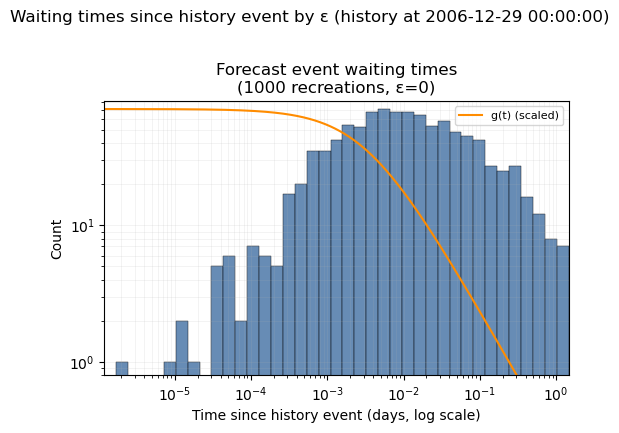

In [28]:
# Waiting-time histograms for each epsilon in recreations_epsilon
history_t_days = float(history_dict["t"])

epsilons = list(epsilon_vec) if "epsilon_vec" in globals() else sorted(recreations_epsilon.keys(), key=float)
epsilons = [eps for eps in epsilons if eps in recreations_epsilon]
if not epsilons:
    epsilons = sorted(recreations_epsilon.keys(), key=float)

delta_t_by_eps = {}
for eps in epsilons:
    pp_events = recreations_epsilon[eps]
    delta_t_by_eps[eps] = pp_events["time"].to_numpy() - history_t_days

all_delta_t = np.concatenate(list(delta_t_by_eps.values()))
positive_all = all_delta_t[all_delta_t > 0]
if positive_all.size == 0:
    raise ValueError("No positive waiting times to plot.")

xmax = max(1e-3, float(np.percentile(positive_all, 99.5)) * 1.1)
xmin = max(1e-6, float(np.min(positive_all)) * 0.5)
n_log_bins = 40
shared_bins = np.geomspace(xmin, xmax, n_log_bins)
t_plot = np.geomspace(xmin, xmax, 500)
g_vals = g(t_plot + history_t_days, history_dict, THETA_0)

max_count = 1
for eps in epsilons:
    positive = delta_t_by_eps[eps][delta_t_by_eps[eps] > 0]
    if positive.size:
        counts, _ = np.histogram(positive, bins=shared_bins)
        max_count = max(max_count, int(counts.max()))

g_scaled = g_vals * (max_count / max(g_vals.max(), 1e-30))
ymin = 0.8
ymax = max(max_count, float(g_scaled.max())) * 1.15

n_eps = len(epsilons)
ncols = min(3, n_eps)
nrows = int(np.ceil(n_eps / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 4.2 * nrows),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for idx, eps in enumerate(epsilons):
    ax = axes[idx // ncols, idx % ncols]
    delta_t_days = delta_t_by_eps[eps]
    positive = delta_t_days[delta_t_days > 0]
    if positive.size == 0:
        ax.text(0.5, 0.5, "No positive waiting times", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"ε = {eps:g}")
        continue

    ax.hist(
        positive,
        bins=shared_bins,
        color="#4c78a8",
        edgecolor="black",
        linewidth=0.35,
        alpha=0.85,
    )
    ax.plot(
        t_plot,
        g_scaled,
        color="darkorange",
        linewidth=1.5,
        label="g(t) (scaled)",
    )

    if eps > 0:
        ax.axvline(eps, color="crimson", linestyle="--", linewidth=1.2, label=f"ε={eps:g}")

    ax.set_title(
        f"Forecast event waiting times\n"
        f"({len(delta_t_days)} recreations, ε={eps:g})"
    )
    ax.grid(which="both", axis="both", alpha=0.25, linewidth=0.4)
    ax.legend(loc="upper right", fontsize=8)

for idx in range(n_eps, nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

for ax in axes.ravel():
    if not ax.axison:
        continue
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_autoscalex_on(False)
    ax.set_autoscaley_on(False)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

for ax in axes[-1, :]:
    if ax.axison:
        ax.set_xlabel("Time since history event (days, log scale)")
for ax in axes[:, 0]:
    if ax.axison:
        ax.set_ylabel("Count")

fig.suptitle(
    f"Waiting times since history event by ε (history at {history_event_time})",
    y=1.02,
)
fig.tight_layout()
plt.show()


2026-06-12 16:17:34,630 - DEBUG - vmin 0.8 vmax 837.1999999999999
2026-06-12 16:17:34,631 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
2026-06-12 16:17:34,634 - DEBUG - vmin 0.8 vmax 837.1999999999999
2026-06-12 16:17:34,634 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04])
2026-06-12 16:17:34,635 - DEBUG - vmin 0.8 vmax 837.1999999999999
2026-06-12 16:17:34,635 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
2026-06-12 16:17:34,657 - DEBUG - vmin 0.8 vmax

2026-06-12 16:17:34,771 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04])
2026-06-12 16:17:34,771 - DEBUG - vmin 0.8 vmax 837.1999999999999
2026-06-12 16:17:34,771 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
2026-06-12 16:17:34,773 - DEBUG - vmin 0.8 vmax 837.1999999999999
2026-06-12 16:17:34,773 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])
2026-06-12 16:17:34,773 - DEBUG - vmin 0.8 vmax 837.1999999999999
2026-06-12 16:17:34,773 - DEBUG - ticklocs arra

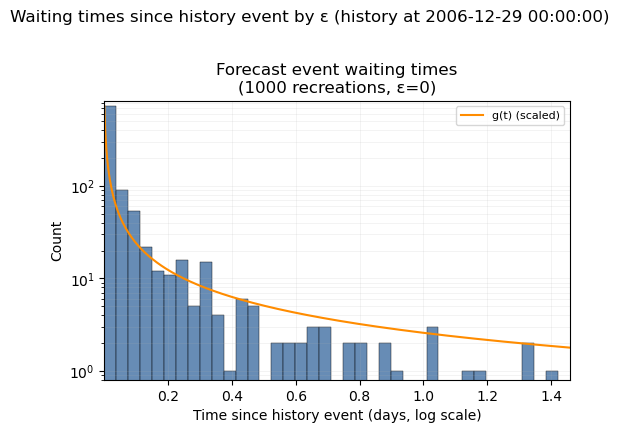

In [37]:
# Waiting-time histograms for each epsilon in recreations_epsilon
history_t_days = float(history_dict["t"])

epsilons = list(epsilon_vec) if "epsilon_vec" in globals() else sorted(recreations_epsilon.keys(), key=float)
epsilons = [eps for eps in epsilons if eps in recreations_epsilon]
if not epsilons:
    epsilons = sorted(recreations_epsilon.keys(), key=float)

delta_t_by_eps = {}
for eps in epsilons:
    pp_events = recreations_epsilon[eps]
    delta_t_by_eps[eps] = pp_events["time"].to_numpy() - history_t_days

all_delta_t = np.concatenate(list(delta_t_by_eps.values()))
positive_all = all_delta_t[all_delta_t > 0]
if positive_all.size == 0:
    raise ValueError("No positive waiting times to plot.")

xmax = max(1e-3, float(np.percentile(positive_all, 99.5)) * 1.1)
xmin = max(1e-6, float(np.min(positive_all)) * 0.5)
n_log_bins = 40
# shared_bins = np.geomspace(xmin, xmax, n_log_bins)
shared_bins = np.linspace(xmin, xmax, n_log_bins)
# t_plot = np.geomspace(xmin, xmax, 500)
t_plot = np.linspace(xmin, xmax, 500)
g_vals = g(t_plot + history_t_days, history_dict, THETA_0)

max_count = 1
for eps in epsilons:
    positive = delta_t_by_eps[eps][delta_t_by_eps[eps] > 0]
    if positive.size:
        counts, _ = np.histogram(positive, bins=shared_bins)
        max_count = max(max_count, int(counts.max()))

g_scaled = g_vals * (max_count / max(g_vals.max(), 1e-30))
ymin = 0.8
ymax = max(max_count, float(g_scaled.max())) * 1.15

n_eps = len(epsilons)
ncols = min(3, n_eps)
nrows = int(np.ceil(n_eps / ncols))
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 4.2 * nrows),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for idx, eps in enumerate(epsilons):
    ax = axes[idx // ncols, idx % ncols]
    delta_t_days = delta_t_by_eps[eps]
    positive = delta_t_days[delta_t_days > 0]
    if positive.size == 0:
        ax.text(0.5, 0.5, "No positive waiting times", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"ε = {eps:g}")
        continue

    ax.hist(
        positive,
        bins=shared_bins,
        color="#4c78a8",
        edgecolor="black",
        linewidth=0.35,
        alpha=0.85,
    )
    ax.plot(
        t_plot,
        g_scaled,
        color="darkorange",
        linewidth=1.5,
        label="g(t) (scaled)",
    )

    if eps > 0:
        ax.axvline(eps, color="crimson", linestyle="--", linewidth=1.2, label=f"ε={eps:g}")

    ax.set_title(
        f"Forecast event waiting times\n"
        f"({len(delta_t_days)} recreations, ε={eps:g})"
    )
    ax.grid(which="both", axis="both", alpha=0.25, linewidth=0.4)
    ax.legend(loc="upper right", fontsize=8)

for idx in range(n_eps, nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

for ax in axes.ravel():
    if not ax.axison:
        continue
    # ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_autoscalex_on(False)
    ax.set_autoscaley_on(False)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

for ax in axes[-1, :]:
    if ax.axison:
        ax.set_xlabel("Time since history event (days, log scale)")
for ax in axes[:, 0]:
    if ax.axison:
        ax.set_ylabel("Count")

fig.suptitle(
    f"Waiting times since history event by ε (history at {history_event_time})",
    y=1.02,
)
fig.tight_layout()
plt.show()


## Apples-to-apples: three ways to forecast the first event

All three approaches target

\[
F(\Delta t) = P(\text{first event in California occurs by } T_h + \Delta t)
\]

where \(T_h\) is `history_event_time`. Plots use **CDF** \(F = 1 - S\), not survival `exp(log_rhs)`.

| Method | Implementation | Model |
|--------|----------------|-------|
| **A. Analytical** | `1 - exp(log_rhs)` | One parent event; \(\lambda=\mu + a_h(x,y)\,g(t)\); degree² `A_h`; no branching |
| **B. Grid point process** | `create_single_realization` → `min` over Voronoi cells | **Same model as A**; inverse transform per cell with random \(U_j\) |
| **C. Classic ETAS** | `simulate_catalog_continuation` | Production simulator: haversine km, discrete aftershocks, magnitude sampling |

### A vs B — should match

For B, the first event is \(T=\min_j T_j\) where each cell solves `log_rhs_j(T_j)=\log U_j`. Then

\[
P(T>\Delta t)=\prod_j \exp(\text{log\_rhs}_j)=\exp\Big(\sum_j \text{log\_rhs}_j\Big),
\qquad
F_B(\Delta t)=1-\exp\Big(\sum_j \text{log\_rhs}_j\Big).
\]

A single California integral `1 - exp(log_rhs)` is almost the same (partitioned `A_h` sums match), but the **exact** B counterpart is the product over cells. With enough Monte Carlo recreations, the B ECDF should sit on that curve (~median **0.03 days** here).

**If A and B looked far apart**, the usual cause is evaluating A on a **coarse linear** \(\Delta t\) grid (`linspace(0,100,400)` → first step \(\approx 0.25\) days) while most probability arrives before **0.05 days**. The next cell uses log-spaced \(\Delta t\) and interpolation for medians.

### C vs A/B — not just distance, not fixed by “first event only”

Keeping only the first simulated event removes later branching, but C still differs because:

- **Spatial kernel**: haversine **km** offsets (`simulate_aftershock_radius`) vs degree² integral `A_h`
- **Generative law**: Poisson **count** of aftershocks with random km locations vs continuous spatial intensity field
- **Background**: Poisson count + uniform times in window (first arrival still ~exponential, but combined with discrete aftershocks)
- **Area**: `polygon_surface` (projected km²) in simulation vs `Geod` + degree² distances in A/B

So C’s median (~**0.006 days**) can be faster than A/B (~**0.03 days**) even for the same parameters.


2026-06-12 15:53:04,743 - DEBUG - vmin 0.0001 vmax 240.45571651732953
2026-06-12 15:53:04,744 - DEBUG - ticklocs array([1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02,
       1.e+03, 1.e+04])
2026-06-12 15:53:04,748 - DEBUG - vmin 0.0001 vmax 240.45571651732953
2026-06-12 15:53:04,749 - DEBUG - ticklocs array([2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6

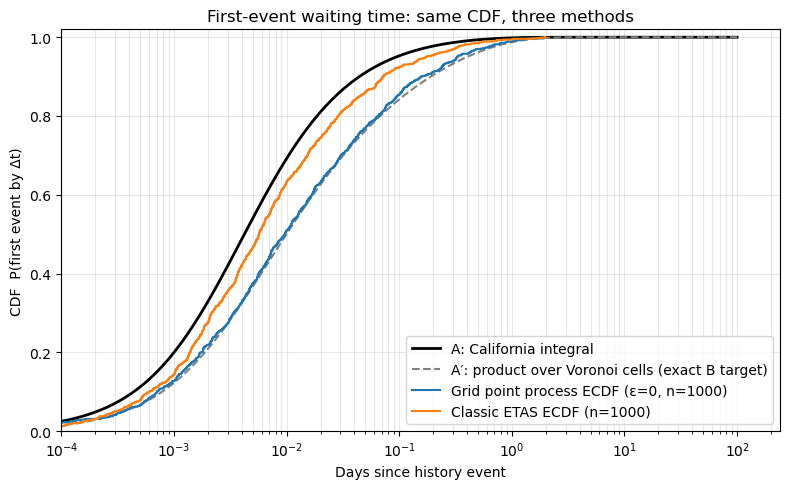

,method,n,median_days,p05_days,p95_days
0,A: California integral,400,0.004216,0.000207,0.094329
1,A′: product over cells,400,0.009967,0.000360,0.399636
2,B: grid point process,1000,0.009643,0.000358,0.327437
3,C: classic ETAS,1000,0.005688,0.000303,0.173319


In [29]:
def _ecdf_positive(samples):
    x = np.sort(np.asarray(samples, dtype=float))
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        return np.array([]), np.array([])
    return x, np.arange(1, x.size + 1, dtype=float) / x.size


def _analytical_median_dt(delta_t, cdf):
    cdf = np.asarray(cdf, dtype=float)
    delta_t = np.asarray(delta_t, dtype=float)
    if not np.any(cdf >= 0.5):
        return np.nan
    return float(np.interp(0.5, cdf, delta_t))


def _analytical_quantile_dt(delta_t, cdf, q):
    cdf = np.asarray(cdf, dtype=float)
    delta_t = np.asarray(delta_t, dtype=float)
    if not np.any(cdf >= q):
        return np.nan
    return float(np.interp(q, cdf, delta_t))


history_t_days = float(history_dict["t"])

# --- 1) Analytical CDFs (log-spaced Δt so the first ~0.01 days are resolved) ---
if "california_lonlat" not in globals():
    california_lonlat = transform(_swap_xy, polygon)

delta_t_analytical = np.geomspace(1e-5, 100.0, 400)
t_eval = delta_t_analytical + history_t_days

log_survival_ca = log_rhs(
    t_eval, history_t_days, california_lonlat, history_dict, THETA_0, A_H_RESOLUTION
)
cdf_ca = 1.0 - np.clip(np.exp(log_survival_ca), 0.0, 1.0)

# Exact B counterpart: product of per-cell survivals
log_survival_cells = np.zeros_like(delta_t_analytical, dtype=float)
for cell in ordered_cells:
    log_survival_cells += log_rhs(
        t_eval, history_t_days, cell, history_dict, THETA_0, A_H_RESOLUTION
    )
cdf_cells = 1.0 - np.clip(np.exp(log_survival_cells), 0.0, 1.0)


# --- 2) Grid point-process recreations (min over Voronoi cells) ---
eps_compare = float(epsilon_vec[0]) if "epsilon_vec" in globals() else 0.0
pp_events = recreations_epsilon[eps_compare]
delta_t_pp = pp_events["time"].to_numpy(dtype=float) - history_t_days
x_pp, y_pp = _ecdf_positive(delta_t_pp)

# --- 3) Classic ETAS catalog continuation ---
if "dt_to_first" not in globals():
    t0 = pd.to_datetime(FORECAST_START, utc=True)
    df_rec = forecast_recreations.loc[forecast_recreations["event_idx"] == 0].copy()
    df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
    dt_to_first = (
        df_rec.loc[df_rec["time"] > t0, "time"] - t0
    ).dt.total_seconds().to_numpy() / 86400.0
x_etas, y_etas = _ecdf_positive(dt_to_first)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    delta_t_analytical,
    cdf_ca,
    color="black",
    linewidth=2,
    label="A: California integral",
)
ax.plot(
    delta_t_analytical,
    cdf_cells,
    color="gray",
    linewidth=1.5,
    linestyle="--",
    label="A′: product over Voronoi cells (exact B target)",
)
if x_pp.size:
    ax.step(x_pp, y_pp, where="post", color="tab:blue", linewidth=1.5, label=f"Grid point process ECDF (ε={eps_compare:g}, n={x_pp.size})")
if x_etas.size:
    ax.step(x_etas, y_etas, where="post", color="tab:orange", linewidth=1.5, label=f"Classic ETAS ECDF (n={x_etas.size})")

ax.set_xscale("log")
ax.set_xlim(left=max(1e-4, np.min([delta_t_analytical[1], x_pp.min() if x_pp.size else 1e-3, x_etas.min() if x_etas.size else 1e-3]) * 0.5))
ax.set_ylim(0, 1.02)
ax.set_xlabel("Days since history event")
ax.set_ylabel("CDF  P(first event by Δt)")
ax.set_title("First-event waiting time: same CDF, three methods")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Summary stats for quick numeric comparison
def _quantile_row(name, x):
    if x.size == 0:
        return {"method": name, "n": 0}
    q = np.quantile(x, [0.05, 0.5, 0.95])
    return {
        "method": name,
        "n": int(x.size),
        "median_days": float(q[1]),
        "p05_days": float(q[0]),
        "p95_days": float(q[2]),
    }


summary = pd.DataFrame(
    [
        {
            "method": "A: California integral",
            "n": int(delta_t_analytical.size),
            "median_days": _analytical_median_dt(delta_t_analytical, cdf_ca),
            "p05_days": _analytical_quantile_dt(delta_t_analytical, cdf_ca, 0.05),
            "p95_days": _analytical_quantile_dt(delta_t_analytical, cdf_ca, 0.95),
        },
        {
            "method": "A′: product over cells",
            "n": int(delta_t_analytical.size),
            "median_days": _analytical_median_dt(delta_t_analytical, cdf_cells),
            "p05_days": _analytical_quantile_dt(delta_t_analytical, cdf_cells, 0.05),
            "p95_days": _analytical_quantile_dt(delta_t_analytical, cdf_cells, 0.95),
        },
        _quantile_row("B: grid point process", delta_t_pp[delta_t_pp > 0]),
        _quantile_row("C: classic ETAS", dt_to_first[dt_to_first > 0]),
    ]
)
summary


### PDF check: histograms vs analytical \(dF/d\Delta t\)

If B (and approximately C for the simplified model) is consistent with the analytical compensator, normalized histograms of \(\Delta t\) should follow the PDF obtained by differentiating the analytical CDF (here: **A′**, product over Voronoi cells).


2026-06-12 15:53:05,021 - DEBUG - vmin 1.1974789231317118e-06 vmax 1.2977806154628362
2026-06-12 15:53:05,021 - DEBUG - ticklocs array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00,
       1.e+01, 1.e+02])
2026-06-12 15:53:05,026 - DEBUG - vmin 1.1974789231317118e-06 vmax 1.2977806154628362
2026-06-12 15:53:05,026 - DEBUG - ticklocs array([2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2

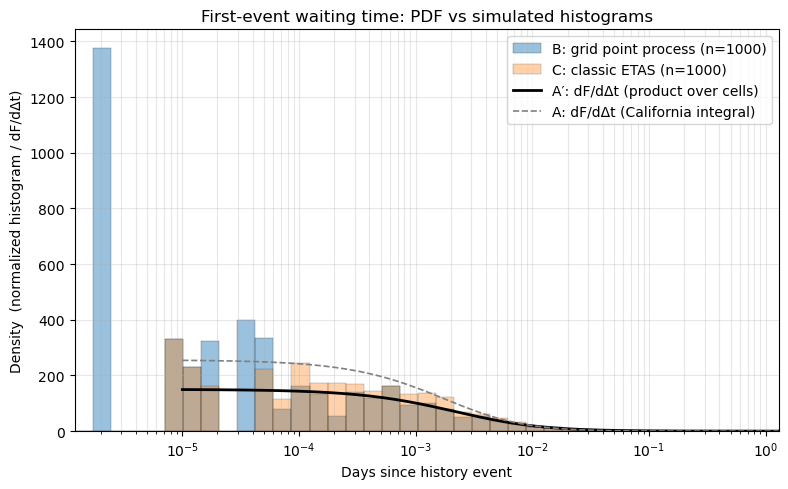

In [30]:
# Requires the previous comparison cell (delta_t_analytical, cdf_cells, delta_t_pp, dt_to_first).
pdf_cells = np.gradient(cdf_cells, delta_t_analytical)
pdf_cells = np.clip(pdf_cells, 0.0, None)

pdf_ca = np.clip(np.gradient(cdf_ca, delta_t_analytical), 0.0, None)

samples_for_bins = []
if "delta_t_pp" in globals():
    samples_for_bins.append(np.asarray(delta_t_pp, dtype=float))
if "dt_to_first" in globals():
    samples_for_bins.append(np.asarray(dt_to_first, dtype=float))
positive_all = np.concatenate(
    [x[(x > 0) & np.isfinite(x)] for x in samples_for_bins if x.size]
) if samples_for_bins else np.array([])
if positive_all.size == 0:
    raise ValueError("Run grid recreations and/or catalog continuation first.")

xmin = max(1e-6, float(np.min(positive_all)) * 0.5)
xmax = max(xmin * 10, float(np.percentile(positive_all, 99.5)) * 1.1)
hist_bins = np.geomspace(xmin, xmax, 40)

fig, ax = plt.subplots(figsize=(8, 5))

delta_t_pos = delta_t_pp[(delta_t_pp > 0) & np.isfinite(delta_t_pp)]
if delta_t_pos.size:
    ax.hist(
        delta_t_pos,
        bins=hist_bins,
        density=True,
        alpha=0.45,
        color="tab:blue",
        edgecolor="black",
        linewidth=0.35,
        label=f"B: grid point process (n={delta_t_pos.size})",
    )

dt_pos = dt_to_first[(dt_to_first > 0) & np.isfinite(dt_to_first)]
if dt_pos.size:
    ax.hist(
        dt_pos,
        bins=hist_bins,
        density=True,
        alpha=0.35,
        color="tab:orange",
        edgecolor="black",
        linewidth=0.35,
        label=f"C: classic ETAS (n={dt_pos.size})",
    )

mask_pdf = (delta_t_analytical >= xmin) & (delta_t_analytical <= xmax) & np.isfinite(pdf_cells)
ax.plot(
    delta_t_analytical[mask_pdf],
    pdf_cells[mask_pdf],
    color="black",
    linewidth=2.0,
    label="A′: dF/dΔt (product over cells)",
)
ax.plot(
    delta_t_analytical[mask_pdf],
    pdf_ca[mask_pdf],
    color="gray",
    linewidth=1.2,
    linestyle="--",
    label="A: dF/dΔt (California integral)",
)

ax.set_xscale("log")
ax.set_xlim(xmin, xmax)
ax.set_xlabel("Days since history event")
ax.set_ylabel("Density  (normalized histogram / dF/dΔt)")
ax.set_title("First-event waiting time: PDF vs simulated histograms")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


Text(0.5, 1.0, 'CDF of time to first event')

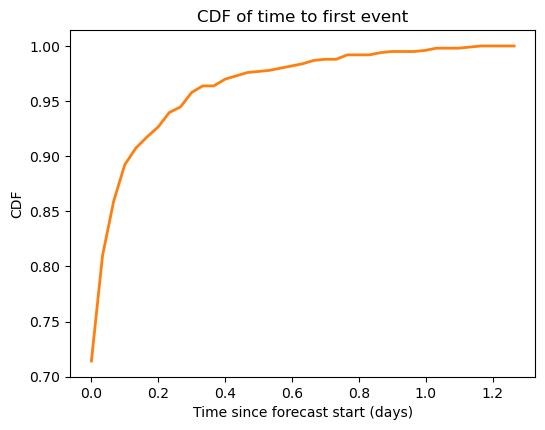

In [31]:

# shared_bins

# xmax = max(1e-3, float(np.percentile(positive_all, 99.5)) * 1.1)
# xmin = max(1e-6, float(np.min(positive_all)) * 0.5)
# n_log_bins = 40


shared_bins_linear = np.linspace(
        xmin,
        xmax,
        n_log_bins,
    )
    
hist, bins = np.histogram(
    positive,
    bins=shared_bins_linear,
)

# CDF
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

fig_cdf, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(bins[:-1], cdf, color="tab:orange", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("CDF")
ax.set_title("CDF of time to first event")
